In [1]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.devices())
print(jax.local_devices()[0].device_kind)

import os
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
from scipy.ndimage import binary_dilation

# import dLux.utils as dlu

import amigo
import dorito

# import astropy

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl


# import ehtplot
# import scienceplots
# import cmasher as cmr

# matplotlib parameters
# plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.6.0 is installed, but it is not compatible with the installed jaxlib version 0.5.3, so it will not be used.
  warnings.warn(


[CudaDevice(id=0)]
NVIDIA GeForce RTX 2080 Ti


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "cal_files/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    # "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # badpix = np.array(file["BADPIX"].data, dtype=bool)
    # im = np.array(file["SLOPE"].data.sum(0))
    # im = np.where(badpix, np.nan, im)
    # mask = binary_dilation(im == np.nanmax(im), iterations=2)
    # file["BADPIX"].data += mask.astype(int)

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}'
    )

    t0 = t

# h


------------------------------

WR137 F380M, Dither 1/4, Roll 192.0deg, 1.7min, 2022-07-13 11:58:59.820
WR137 F380M, Dither 2/4, Roll 192.0deg, 1.7min, 2022-07-13 12:03:02.507
WR137 F380M, Dither 4/4, Roll 192.0deg, 1.7min, 2022-07-13 12:11:07.947

------------------------------

HD 228337 F380M, Dither 1/1, Roll 189.5deg, 6.8min, 2022-07-15 11:54:31.525
WR137 F380M, Dither 1/4, Roll 189.8deg, 6.8min, 2022-07-15 12:51:09.154

------------------------------

WR137 F380M, Dither 1/4, Roll 162.7deg, 1.7min, 2022-08-08 19:00:58.197
WR137 F380M, Dither 2/4, Roll 162.7deg, 1.7min, 2022-08-08 19:05:00.885
WR137 F380M, Dither 3/4, Roll 162.7deg, 1.7min, 2022-08-08 19:09:03.509
WR137 F380M, Dither 4/4, Roll 162.7deg, 1.7min, 2022-08-08 19:13:06.261
HD 228337 F380M, Dither 1/4, Roll 162.0deg, 1.7min, 2022-08-08 20:06:31.377
HD 228337 F380M, Dither 2/4, Roll 162.0deg, 1.7min, 2022-08-08 20:10:33.041
HD 228337 F380M, Dither 3/4, Roll 162.0deg, 1.7min, 2022-08-08 20:14:35.729
HD 228337 F380M, Dith

/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [5]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

cal_exposures = [
    amigo.model_fits.SplineVisFit(file, joint_fit=False) for file in cal_files  # [1:]
]
sci_exposures = [
    amigo.model_fits.SplineVisFit(file, joint_fit=False) for file in sci_files  # [5:]
]
# exposures = cal_exposures + sci_exposures
exposures = cal_exposures[0:2]

model = amigo.core_models.AmigoModel(
    exposures,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.SUB80Detector(),
    read=amigo.read_models.ReadModel(),
    vis_model=amigo.vis_models.LogVisModel(
        load_dict(cache + "vis_basis.npy"), n_basis=420
    ),
    state=load_dict(cache + "cal_model.npy"),
)

In [6]:
for exp in exposures:
    print(exp.star)
    amigo.plotting.summarise_fit(model, exp, residuals=True)

HD 228337


2025-05-22 15:24:25.900264: E external/xla/xla/stream_executor/cuda/cuda_timer.cc:72] CUDA error: Could not synchronize CUDA stream: CUDA_ERROR_MISALIGNED_ADDRESS: misaligned address
2025-05-22 15:24:25.900291: E external/xla/xla/stream_executor/cuda/cuda_event.cc:49] CUDA error: Error destroying CUDA event: CUDA_ERROR_MISALIGNED_ADDRESS: misaligned address
2025-05-22 15:24:25.900294: E external/xla/xla/stream_executor/cuda/cuda_event.cc:49] CUDA error: Error destroying CUDA event: CUDA_ERROR_MISALIGNED_ADDRESS: misaligned address
E0522 15:24:25.900297  743321 cuda_executor.cc:580] error deallocating host memory at 0x717d15200200: INTERNAL: CUDA error: : CUDA_ERROR_MISALIGNED_ADDRESS: misaligned address


XlaRuntimeError: INTERNAL: CUDA error: Failed to enqueue async memset operation: CUDA_ERROR_MISALIGNED_ADDRESS: misaligned address

In [ ]:
n_epoch = 50

config = {
    "positions": sgd(5e-1, 0),
    "fluxes": sgd(2e-1, 0),
    "aberrations": sgd(3e-2, 4),
    "spectra": sgd(3e-2, 10),
    # "phases": sgd(5e-2, 20),
    # "amplitudes": sgd(5e-2, 20),
}

trainer = amigo.fitting.Trainer(
    cache=os.path.join(amigo_cache, "fishers/"),
)

trainer = trainer.populate_fishers(
    # model.set("detector.ramp.bleed", False).set("params", params),
    model,
    exposures,
    hessians=load_dict(cache + "jac_outputs.npy")["hessian"],
    parameters=list(config.keys()),
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    # batches=batches,
    # batches=amigo.fitting.batch_exposures(cal_exposures, n_batch=3),
    batches=exposures,
)

  0%|          | 0/50 [00:00<?, ?it/s]

Compiling Loss function...


XlaRuntimeError: UNIMPLEMENTED: No registered implementation for custom call to cusolver_getrf_ffi for platform CUDA

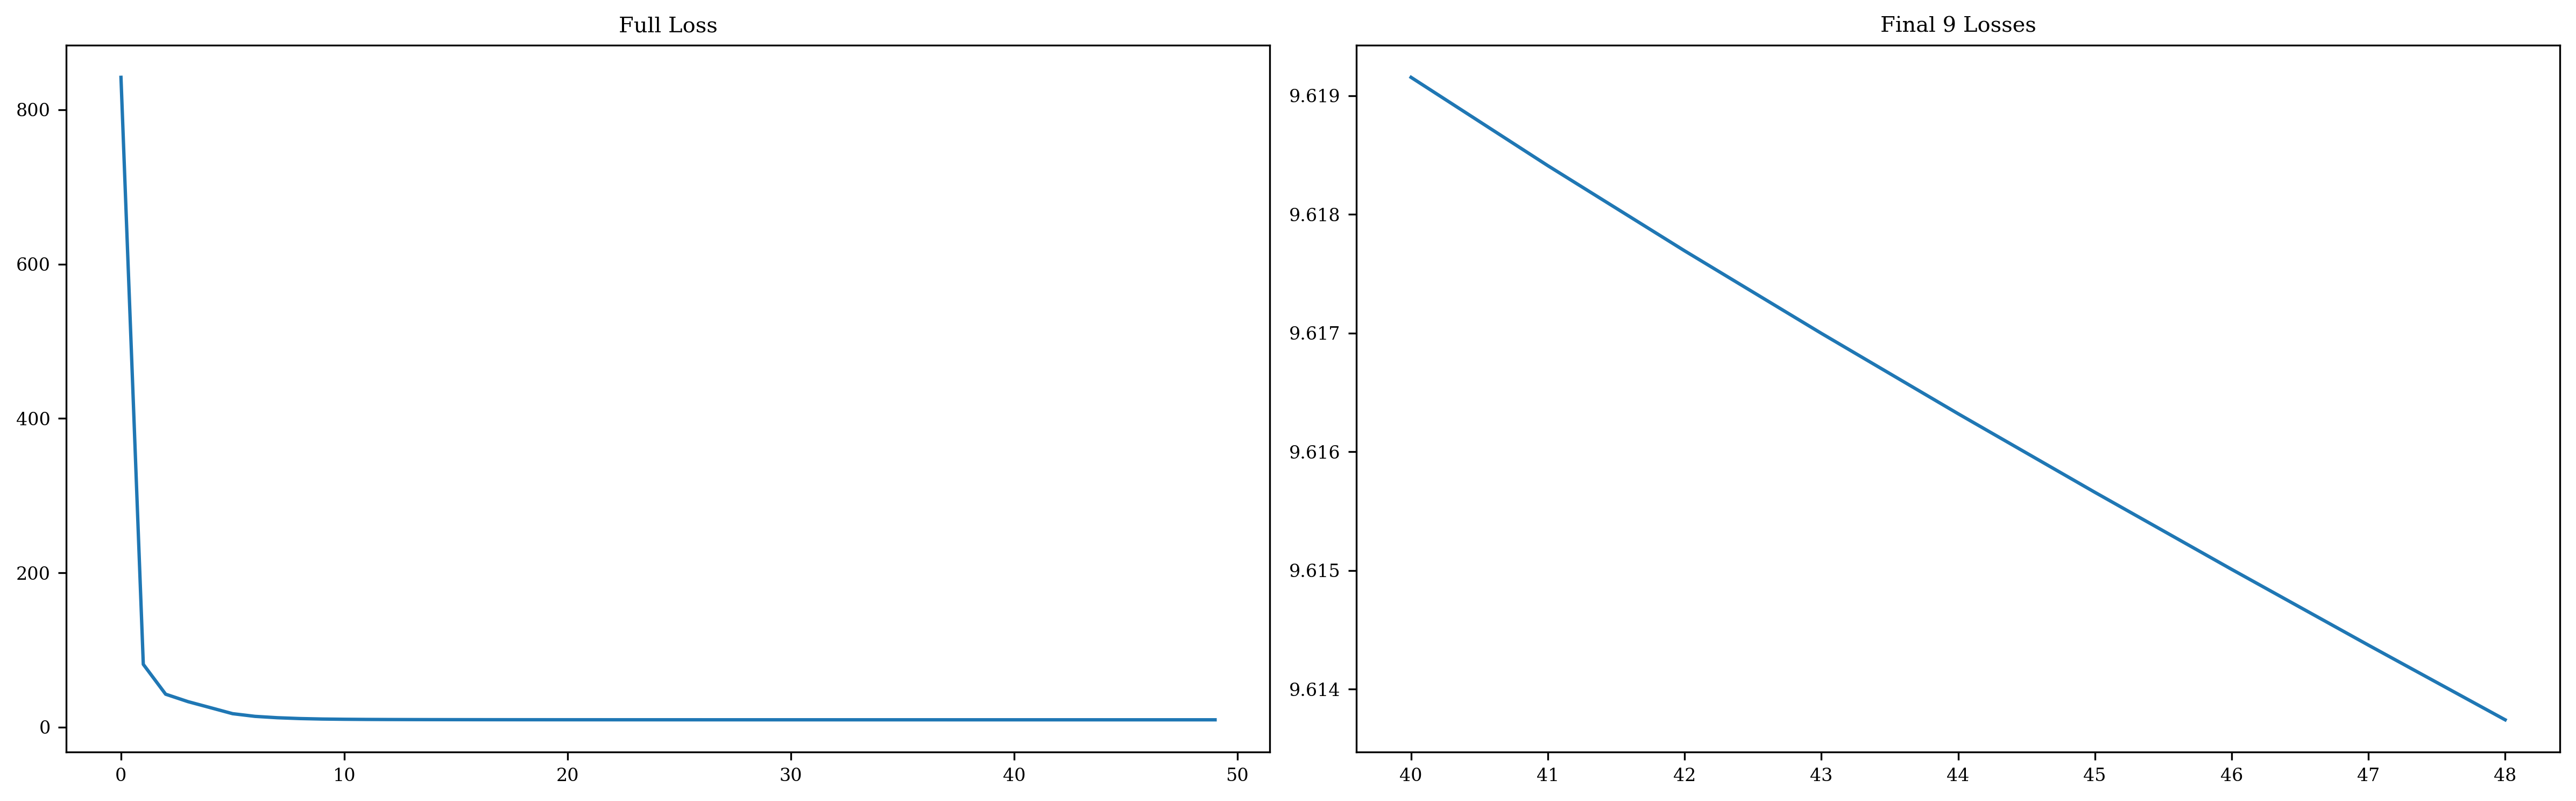

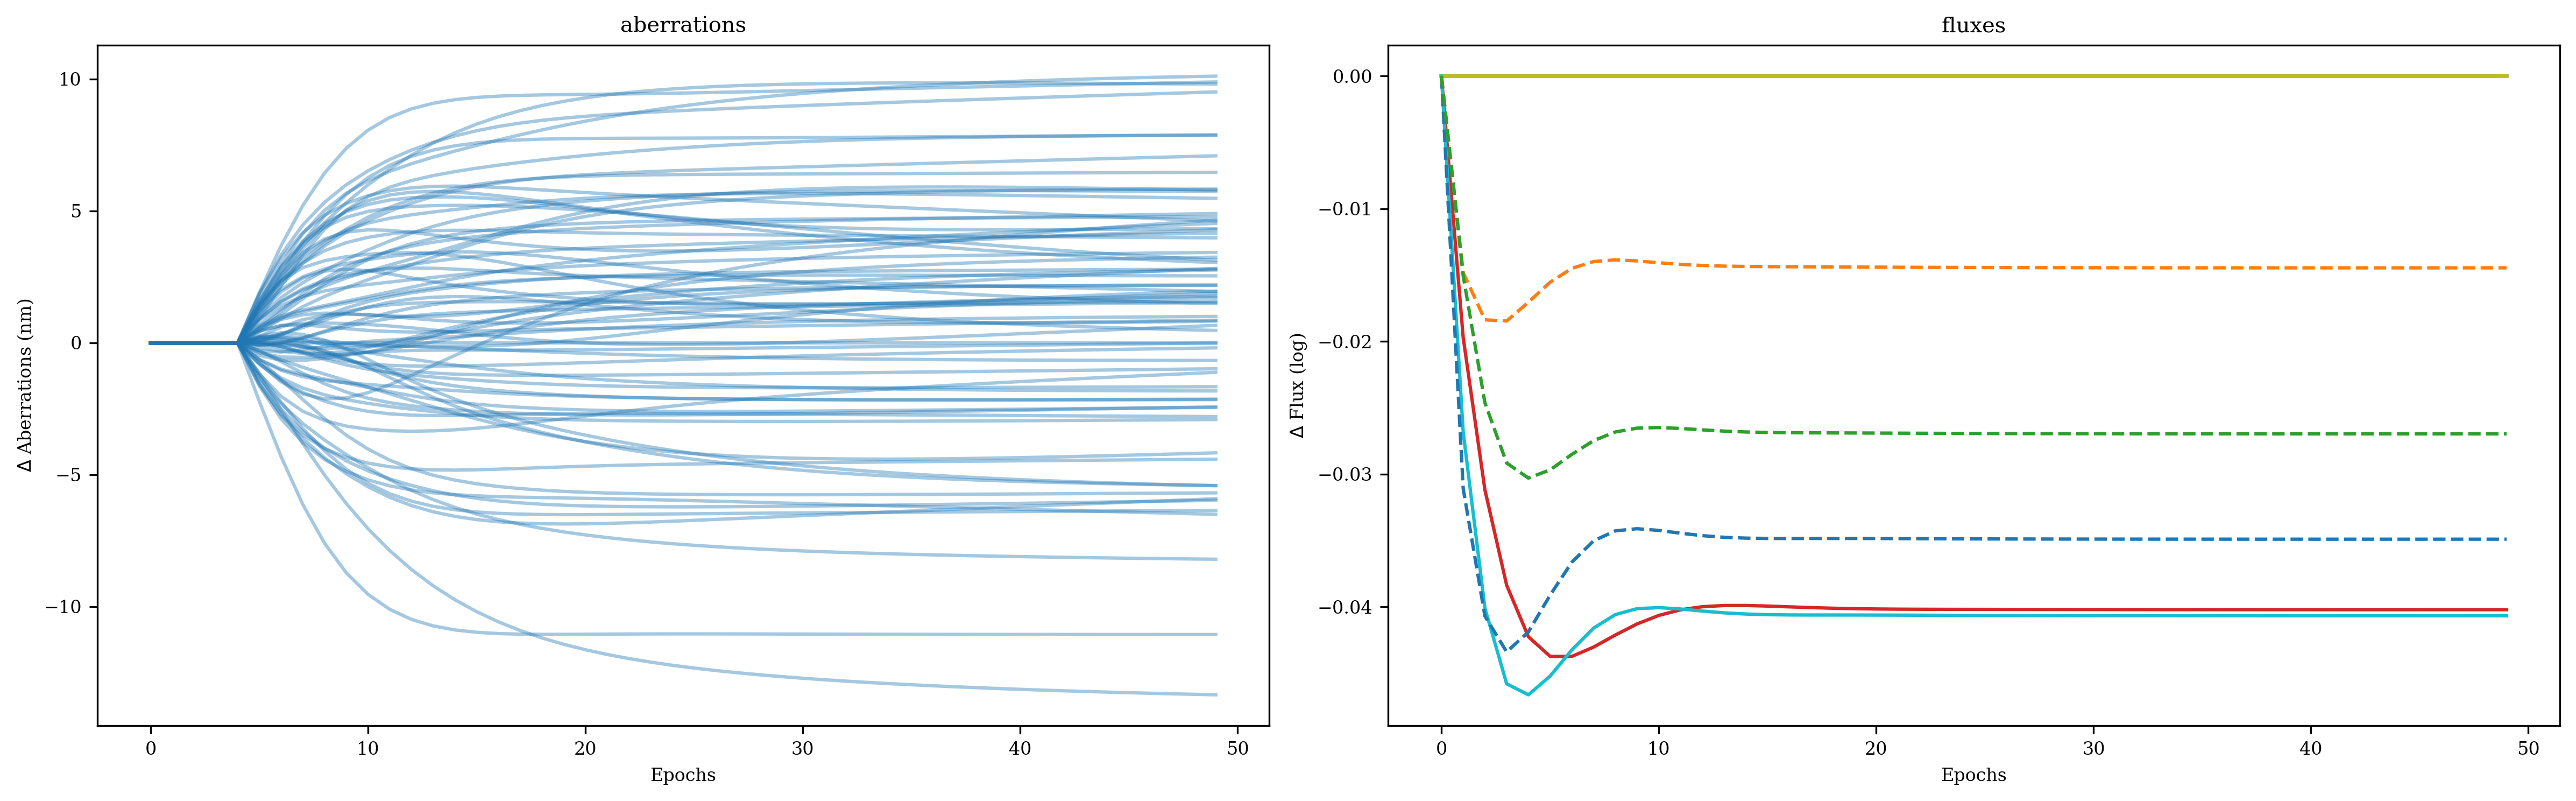

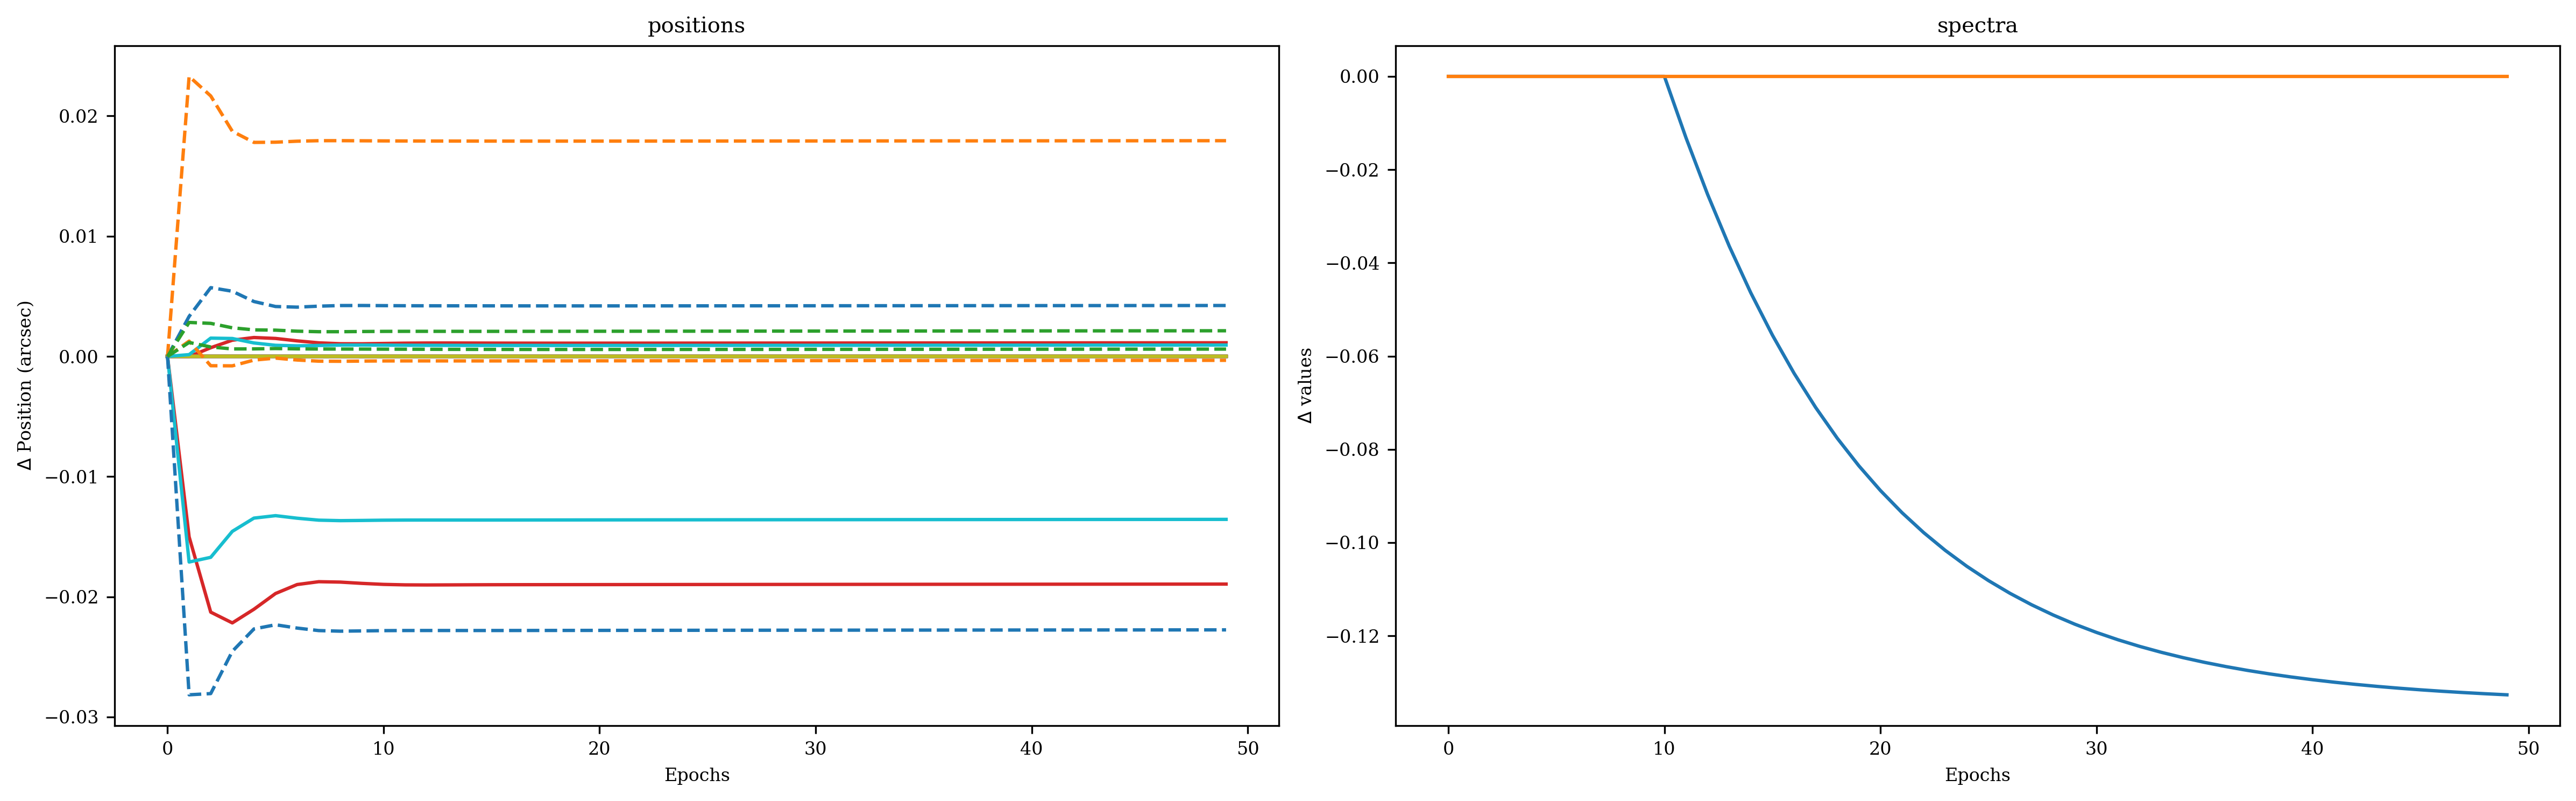

HD 228337


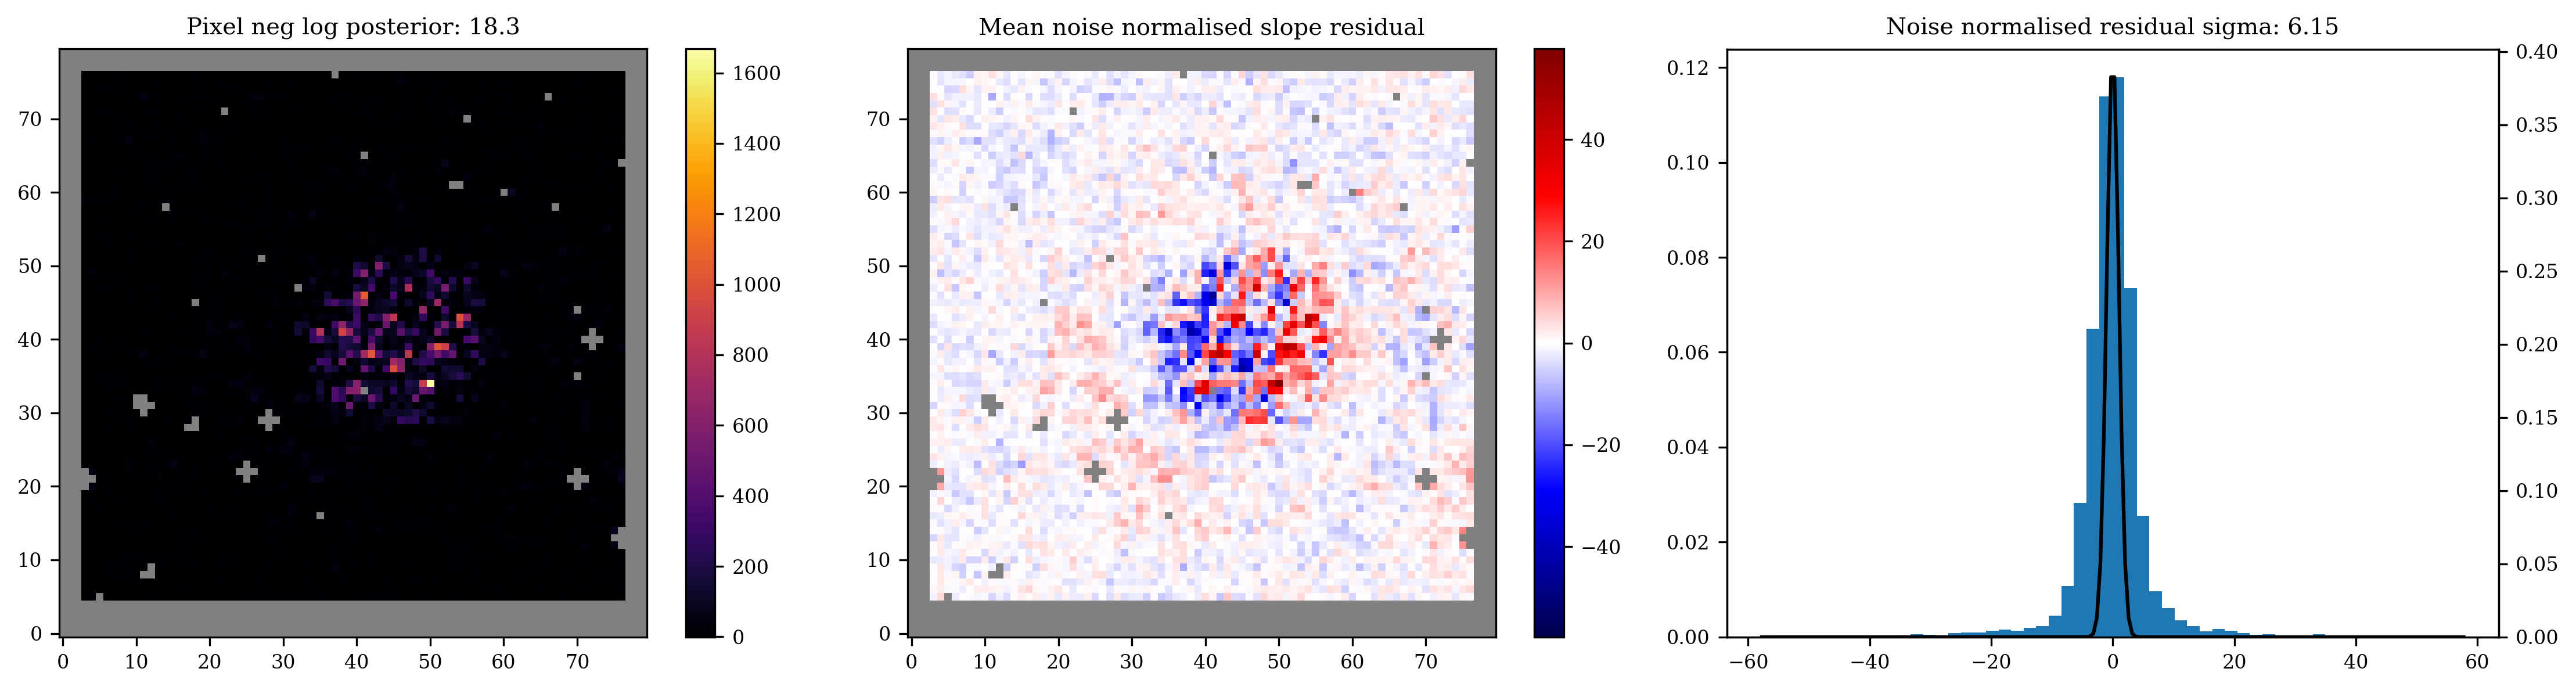

HD 228337


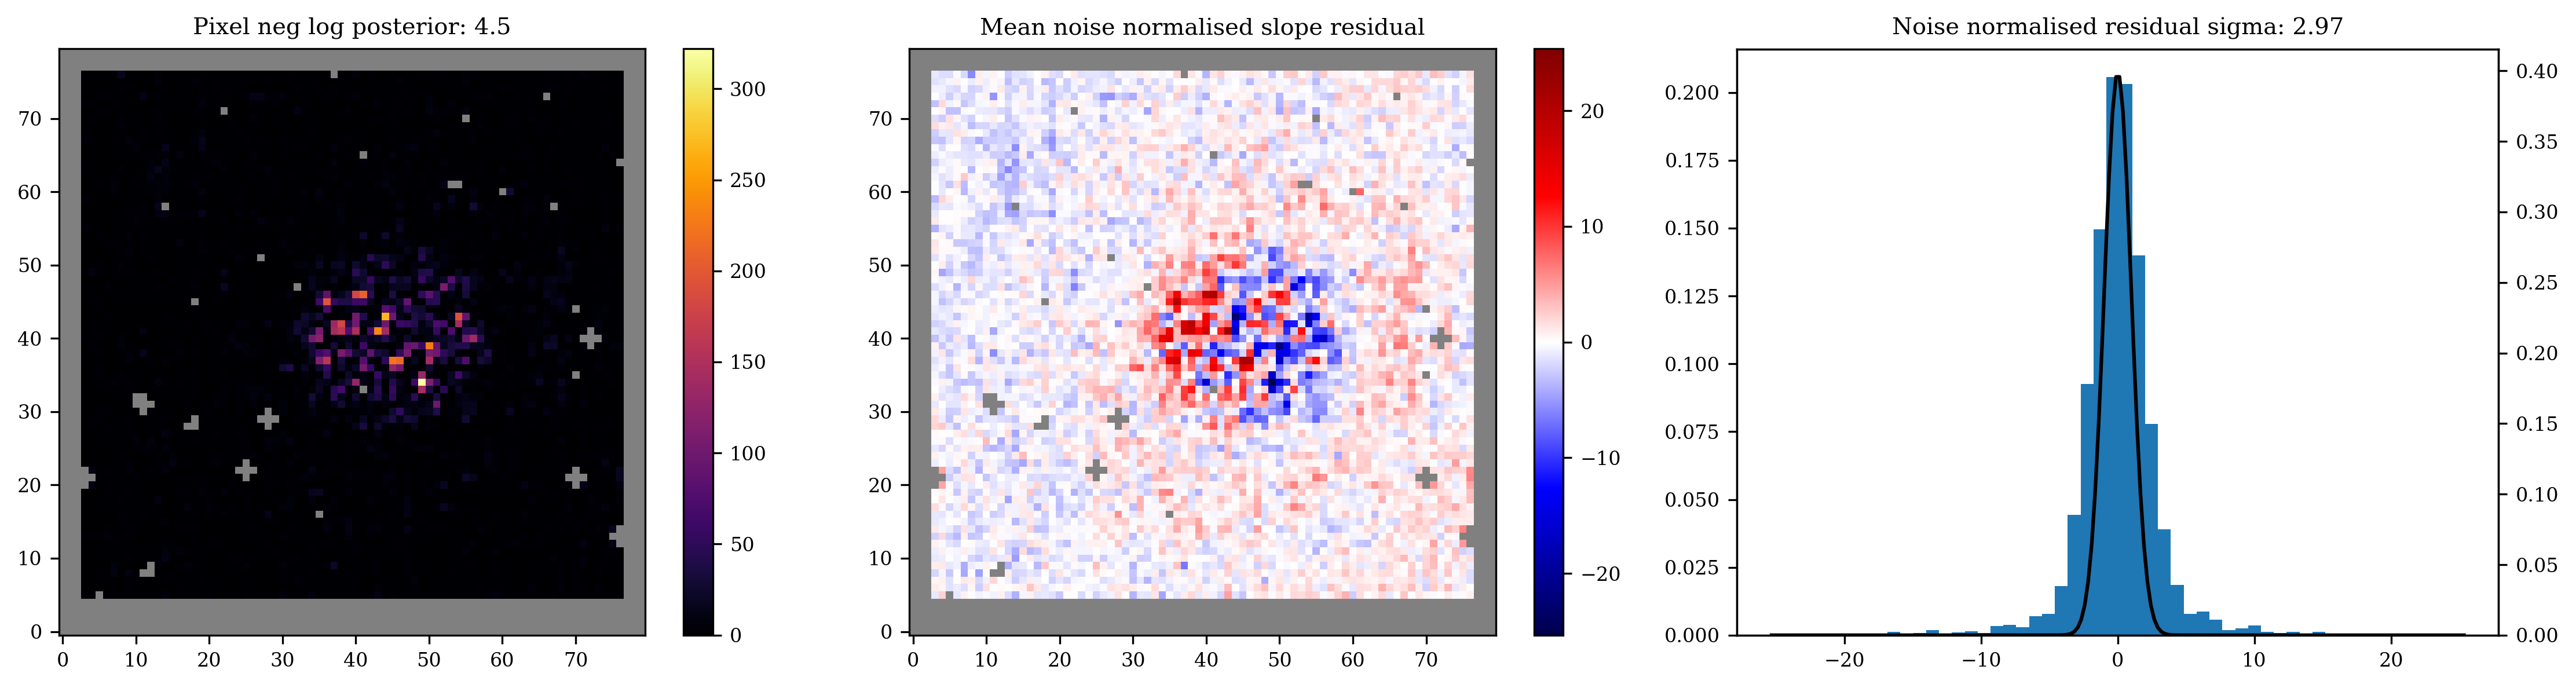

HD 228337


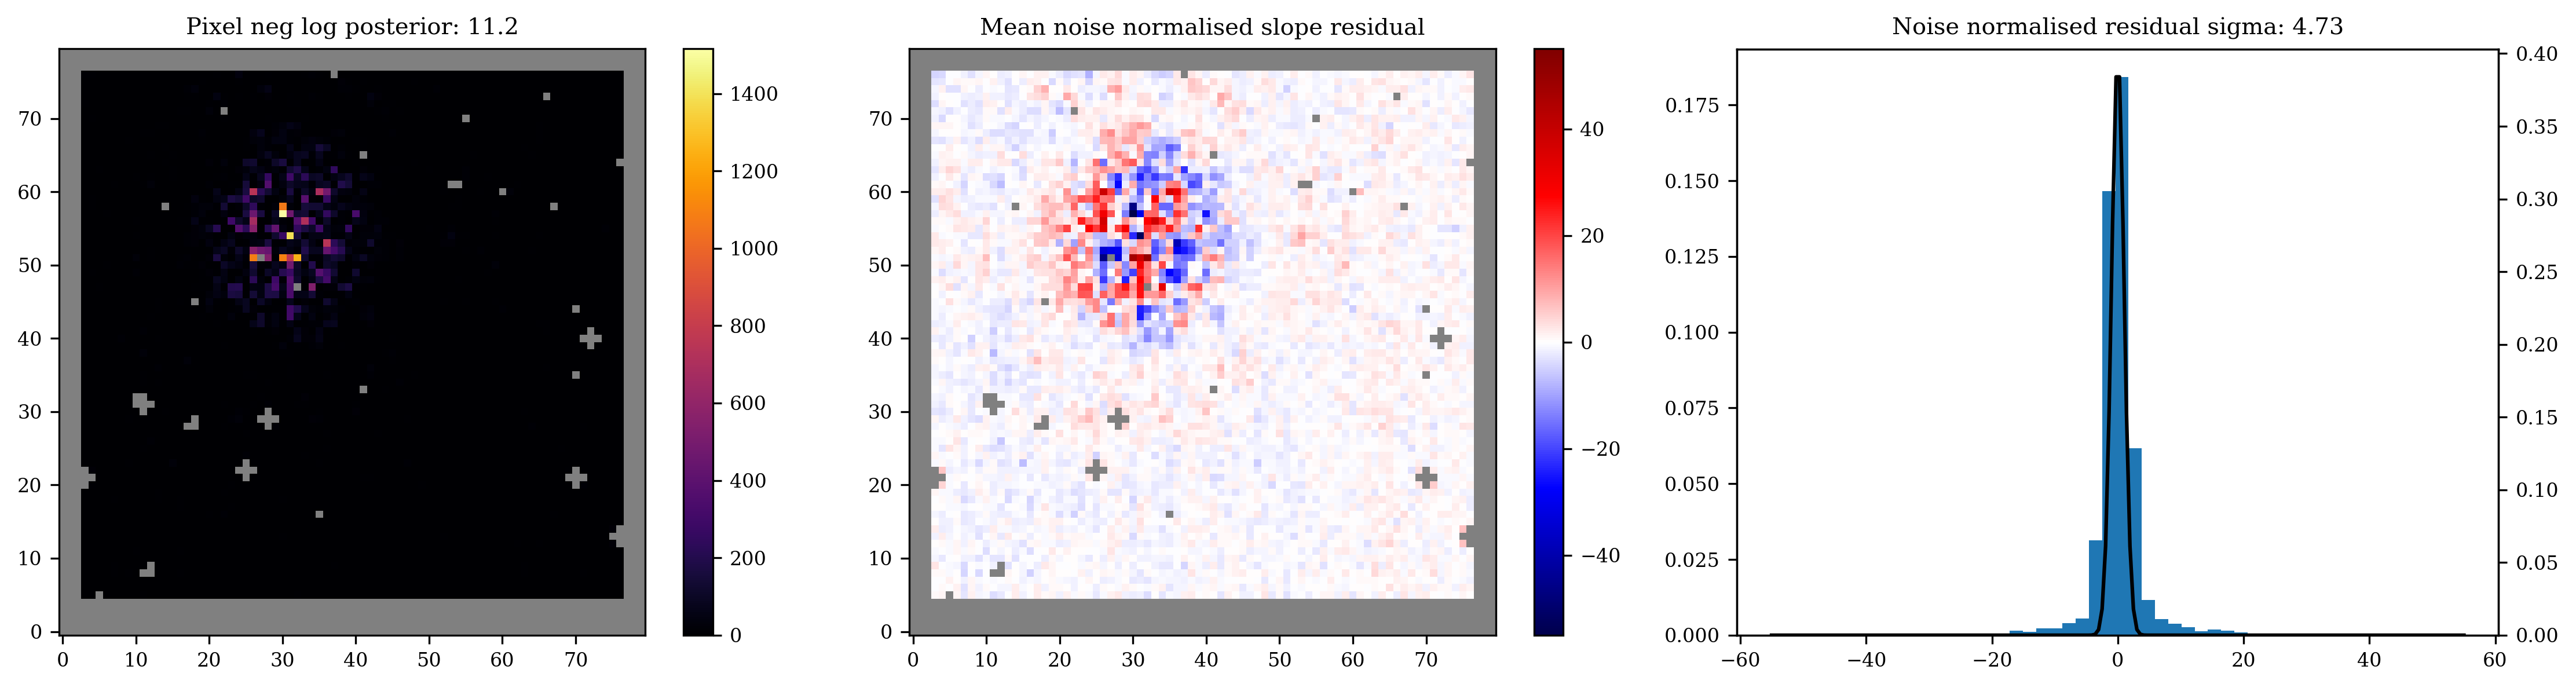

HD 228337


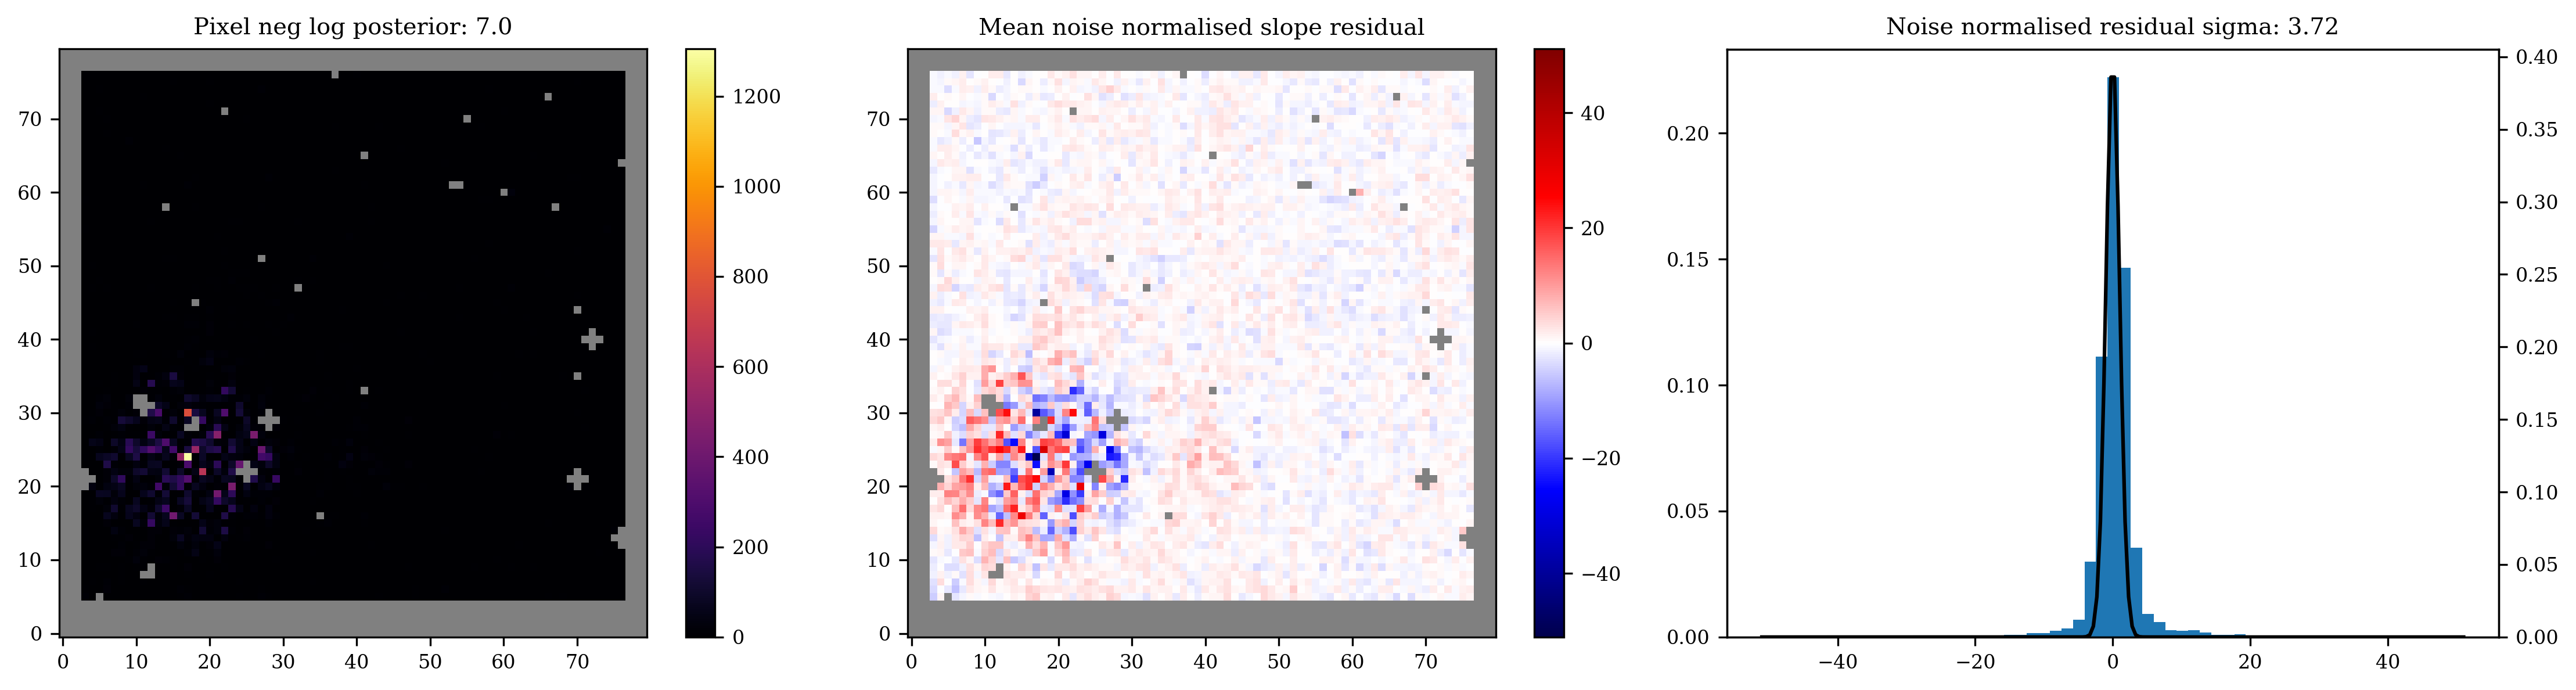

HD 228337


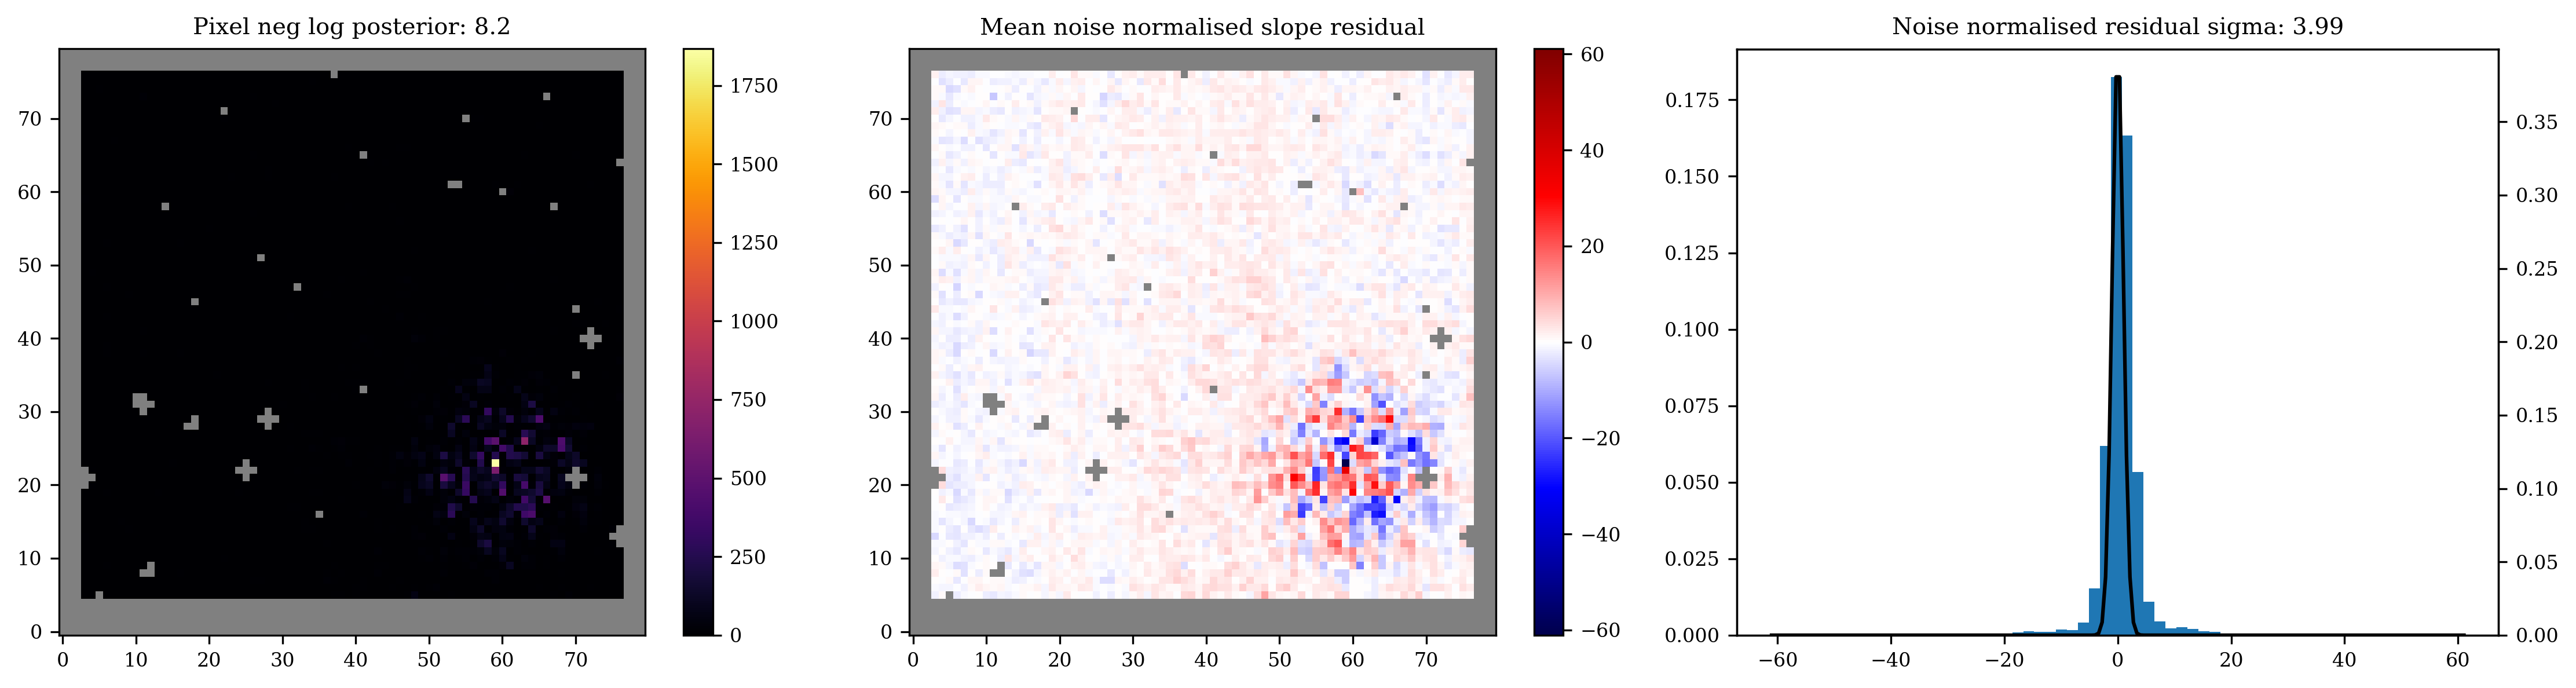

In [ ]:
losses = np.array([v for v in result.losses.values()]).mean(0)

amigo.plotting.plot_losses(losses, start=int(0.8 * n_epoch))
amigo.plotting.plot(result.history)

# for exp in exposures:
for exp in cal_exposures:
    print(exp.star)
    amigo.plotting.summarise_fit(result.model, exp)

In [ ]:
# zdx.experimental.serialise(output_path + "firstbigrun.zdx", result.model.params)

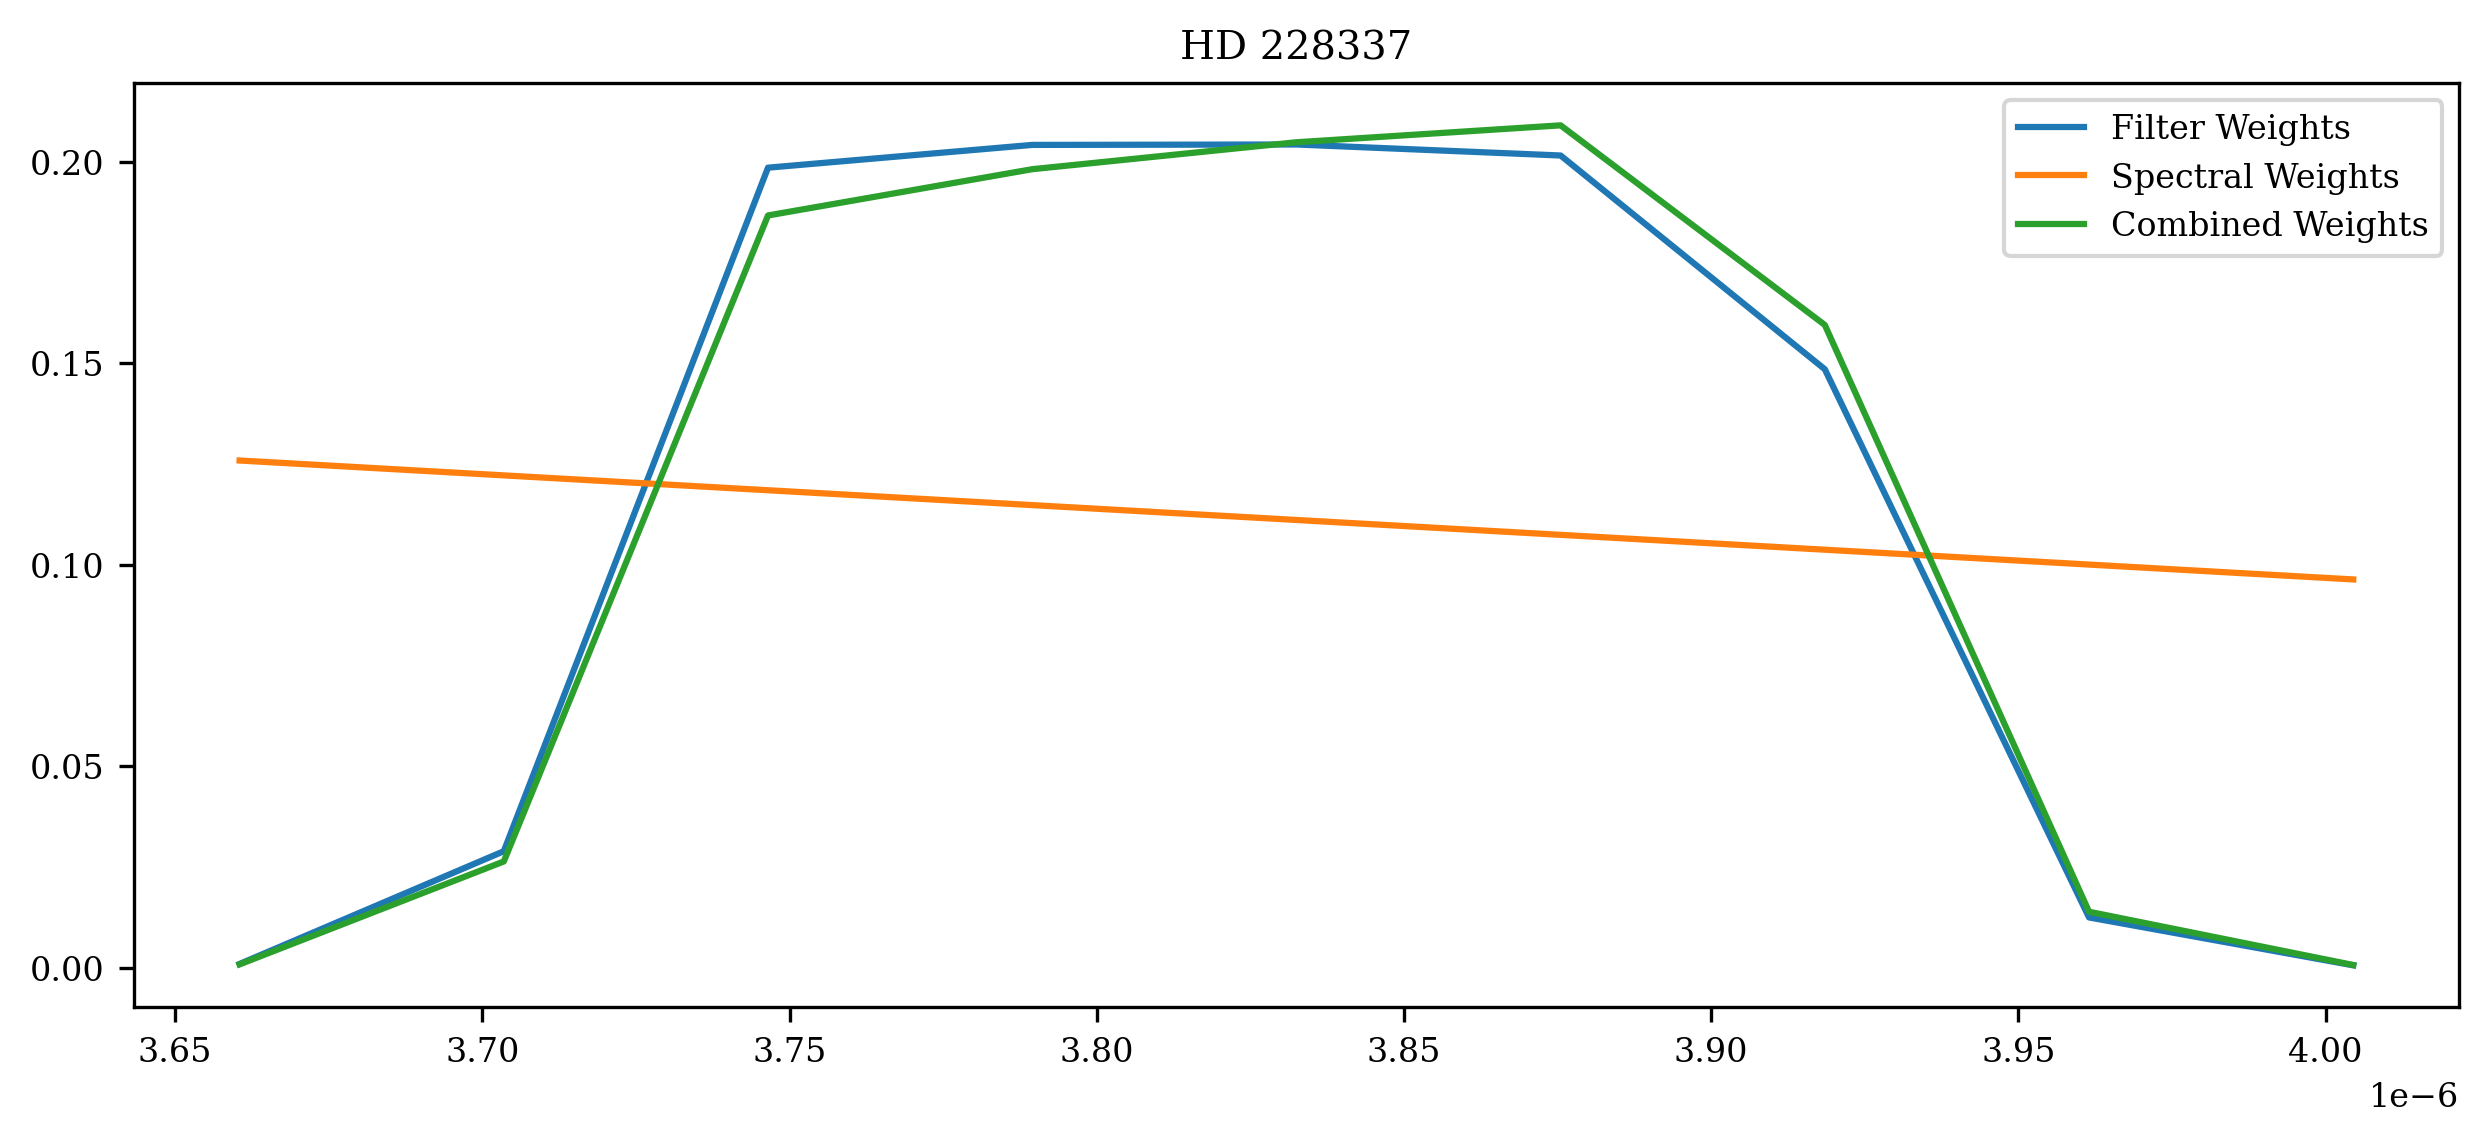

In [ ]:
stars = list(set([exp.star for exp in exposures]))

for targ_star in stars:
    plt.figure(figsize=(10, 4))
    plt.title(f"{targ_star}")
    for key, spec in result.model.spectra.items():
        star, filt = key.split("_")

        if star != targ_star:
            continue

        wavels, filt_weights = model.filters[filt]
        xs = np.linspace(-1, 1, len(wavels), endpoint=True)
        spectra_slopes = 1 + spec * xs
        weights = filt_weights * spectra_slopes  # * wavels

        #
        filt_weights = filt_weights / filt_weights.sum()
        spectra_slopes = spectra_slopes / spectra_slopes.sum()
        weights = weights / weights.sum()

        plt.plot(wavels, weights, label="Filter Weights")
        plt.plot(wavels, spectra_slopes, label="Spectral Weights")
        plt.plot(wavels, filt_weights, label="Combined Weights")

    plt.legend()
    plt.show()

In [ ]:
def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)

In [ ]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams
from jax.flatten_util import ravel_pytree


@eqx.filter_jit
def fun(X, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    latent_params = X
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, latent_params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    loss, _ = loss_fn(model, exp)
    return loss


params = ["amplitudes", "phases", "fluxes", "spectra"]

final_model = result.model

args_out = {}
sols_out = {}
for exp in exposures:
    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    X = initial_params
    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    print("Initial loss:", fun(X, args))
    solver = optx.BFGS(rtol=1e-4, atol=1e-4)  # , verbose=frozenset({"loss"}))
    sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=1024)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 18.900042125567627
Final loss: 4.214681880000653
568 165


Initial loss: 4.399542311521779
Final loss: 1.2727670163474893
672 194


Initial loss: 11.180795662395525
Final loss: 2.613716207566241
684 205


Initial loss: 6.987213193409129
Final loss: 2.3162985986896736
640 209


Initial loss: 8.103725226655225
Final loss: 2.117982330206042
723 243




In [ ]:
cal_spectra = []
sci_spectra = []
for key, args in args_out.items():
    proj_mats = args[3]

    # print(args[3])

    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    exp = args[1]
    if exp.calibrator:
        cal_spectrum = model_params[exp.map_param("spectra")]
        cal_spectra.append(cal_spectrum)
    else:
        sci_spectrum = model_params[exp.map_param("spectra")]
        sci_spectra.append(sci_spectrum)


cal_spectra = np.array(cal_spectra).mean()
sci_spectra = np.array(sci_spectra).mean()

for exp in exposures:
    if exp.calibrator:
        final_model = final_model.set(exp.map_param("spectra"), cal_spectra)
    else:
        final_model = final_model.set(exp.map_param("spectra"), sci_spectra)

result = result.set("model", final_model)

HD 228337
(Array(4.2426289, dtype=float64), ())


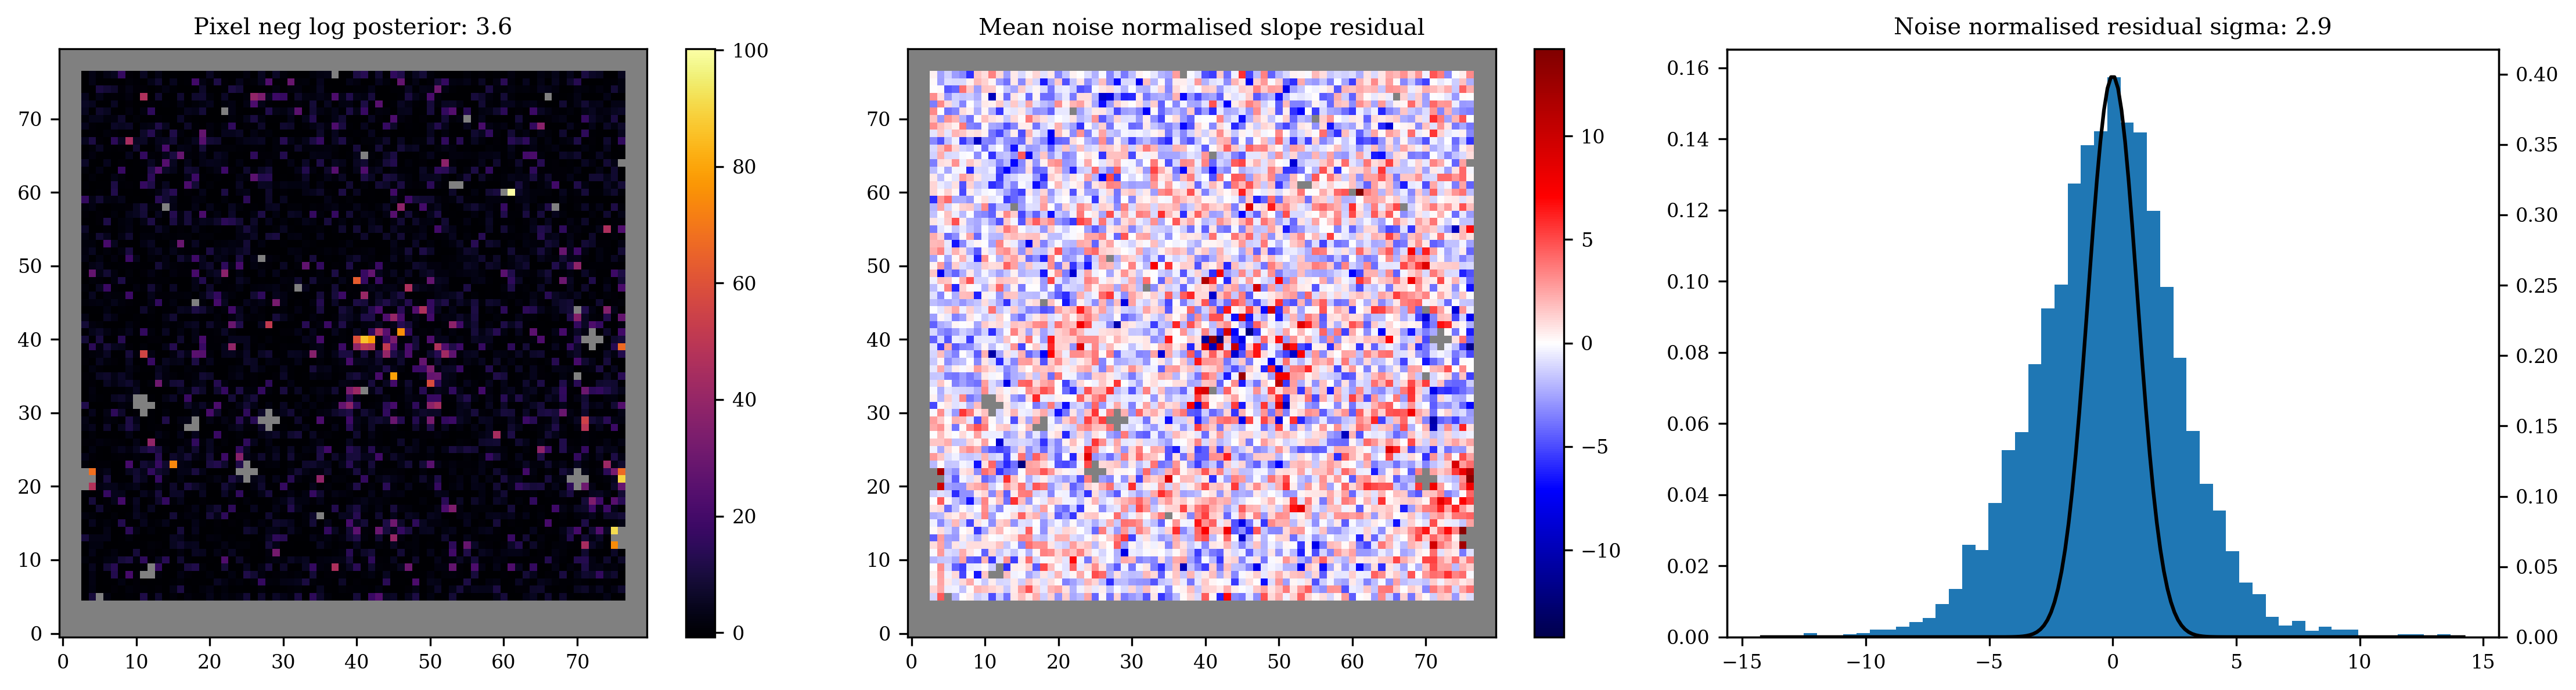

HD 228337
(Array(1.2801501, dtype=float64), ())


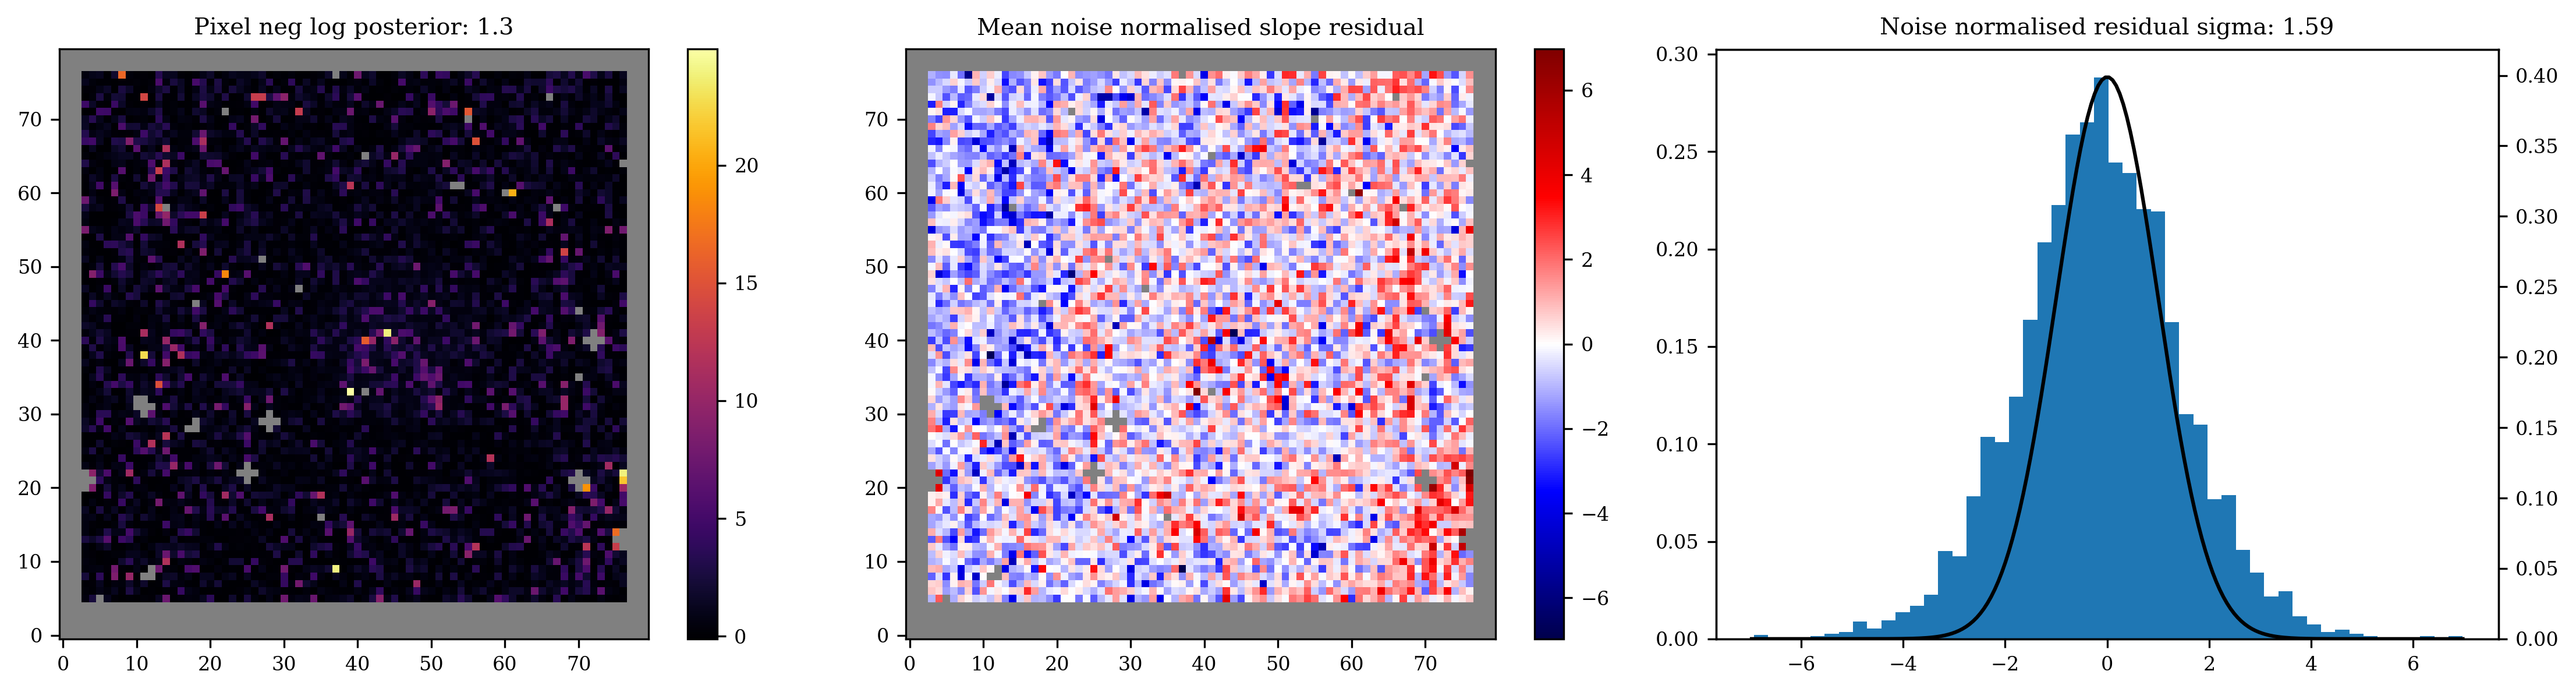

HD 228337
(Array(2.62453158, dtype=float64), ())


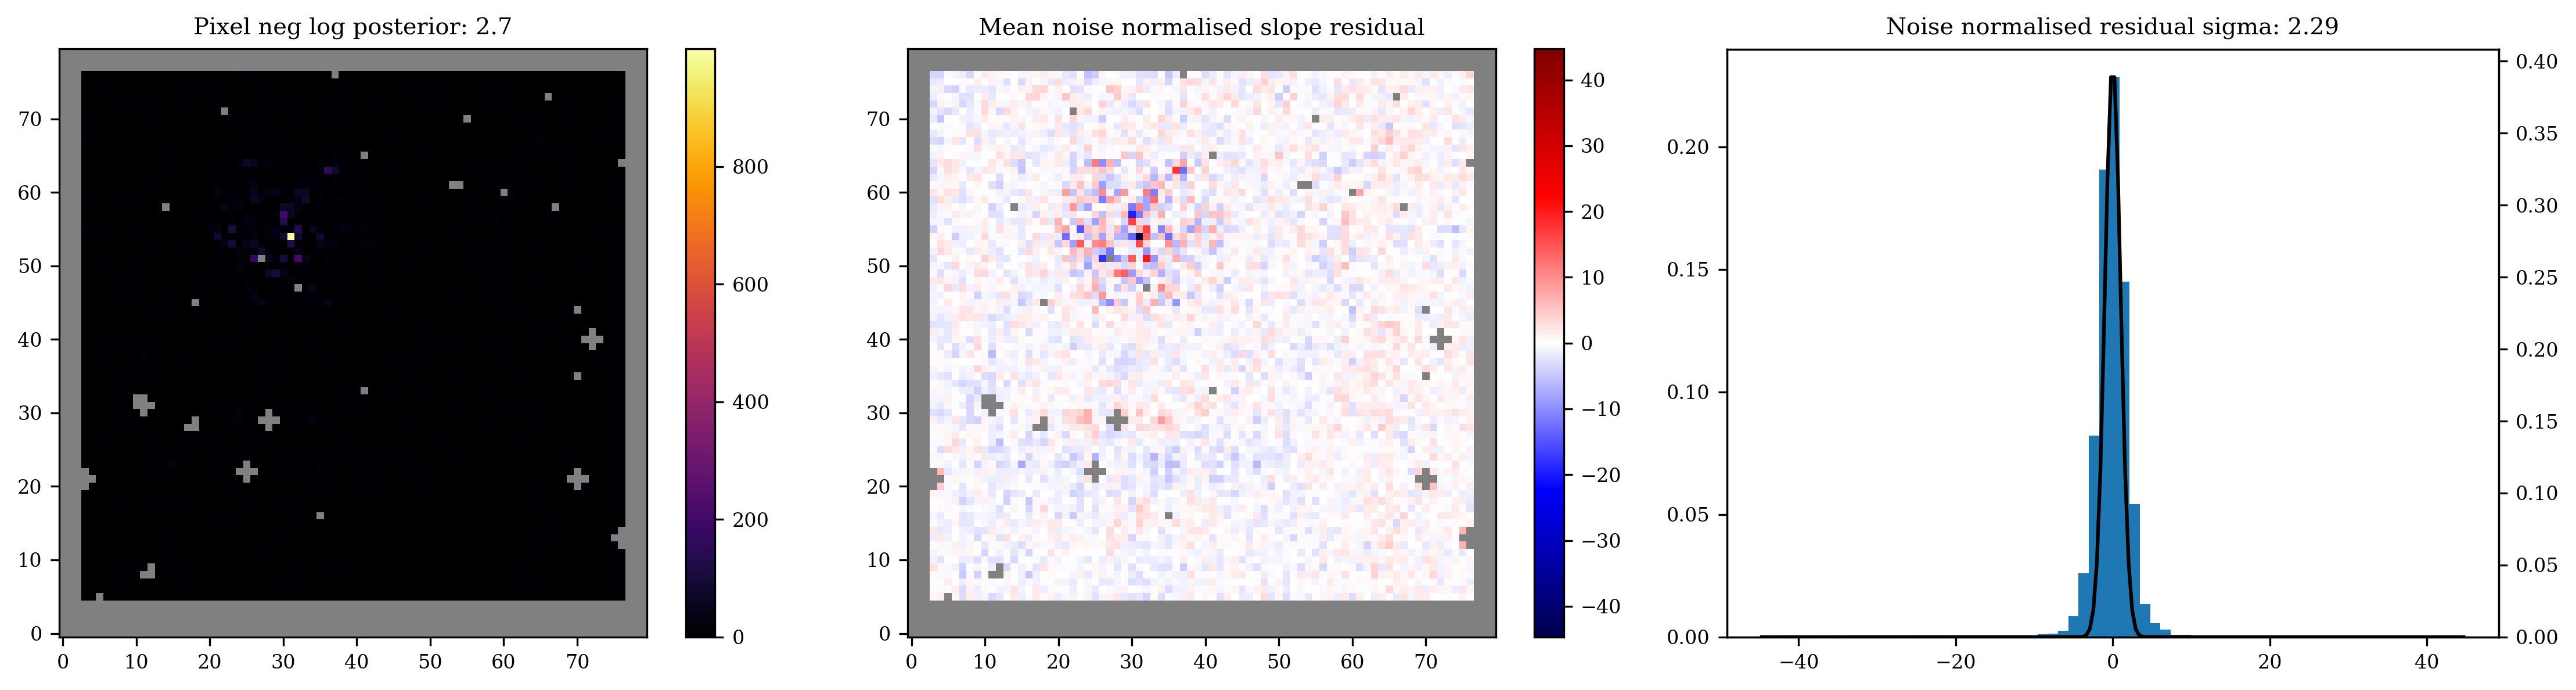

HD 228337
(Array(2.32297606, dtype=float64), ())


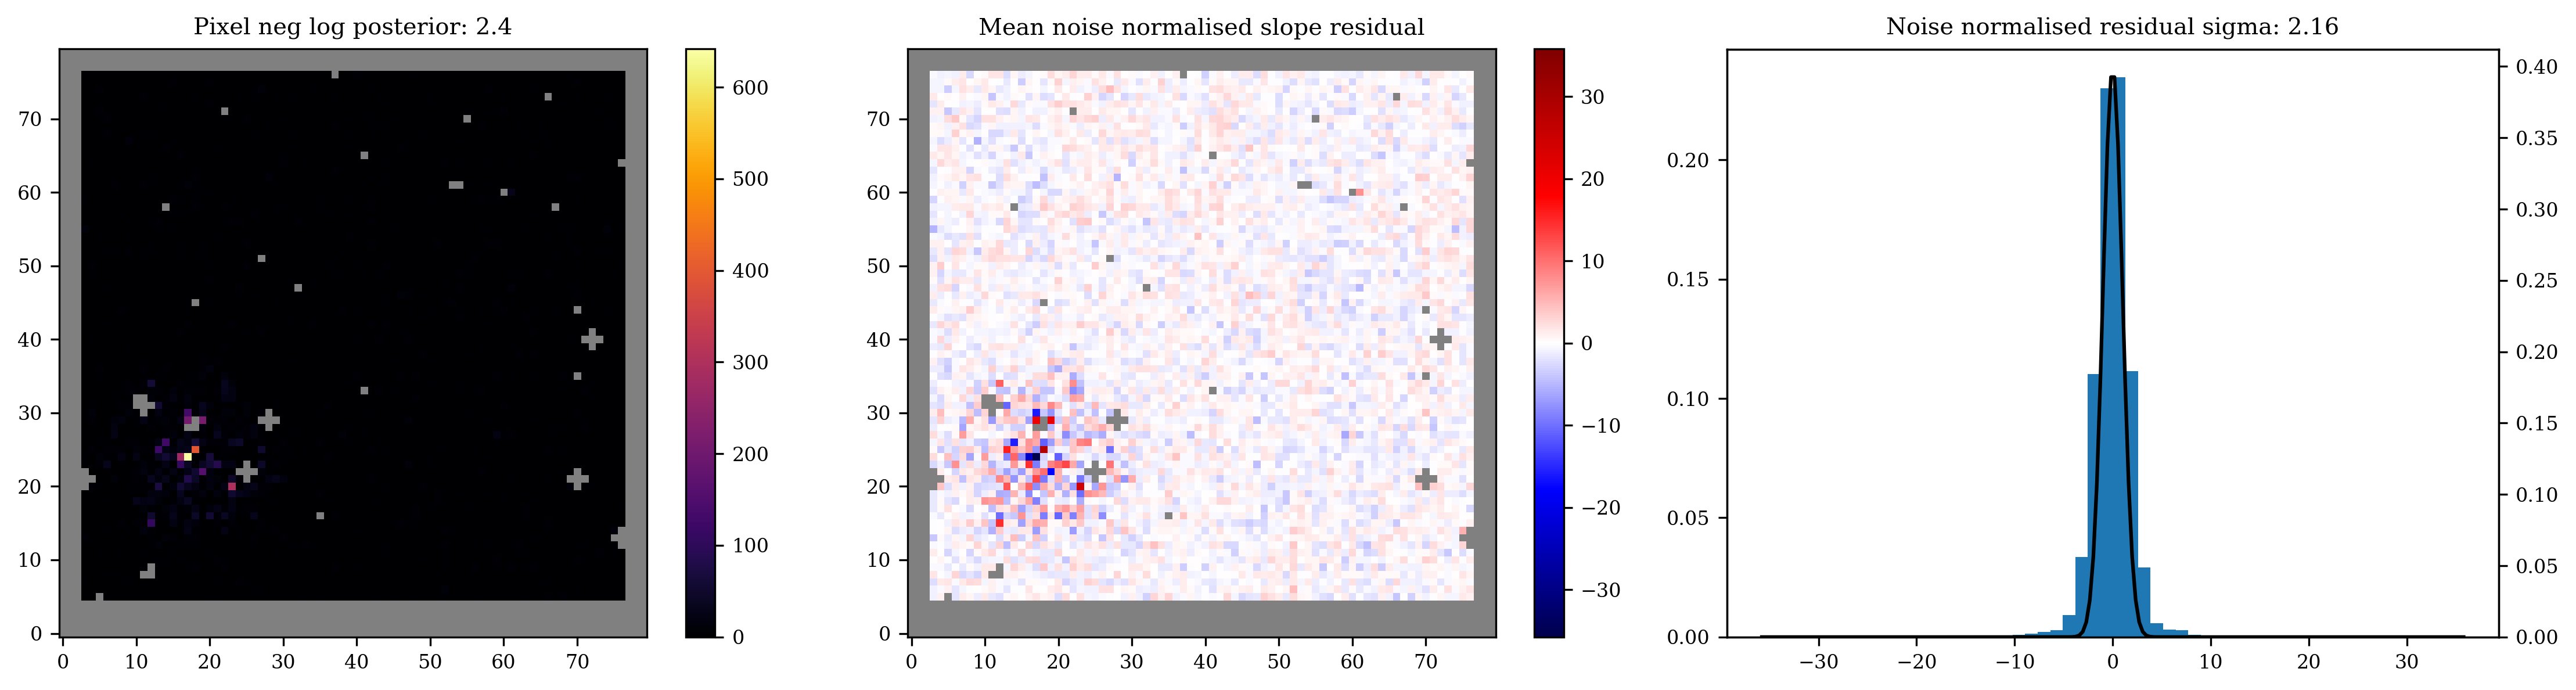

HD 228337
(Array(2.13924682, dtype=float64), ())


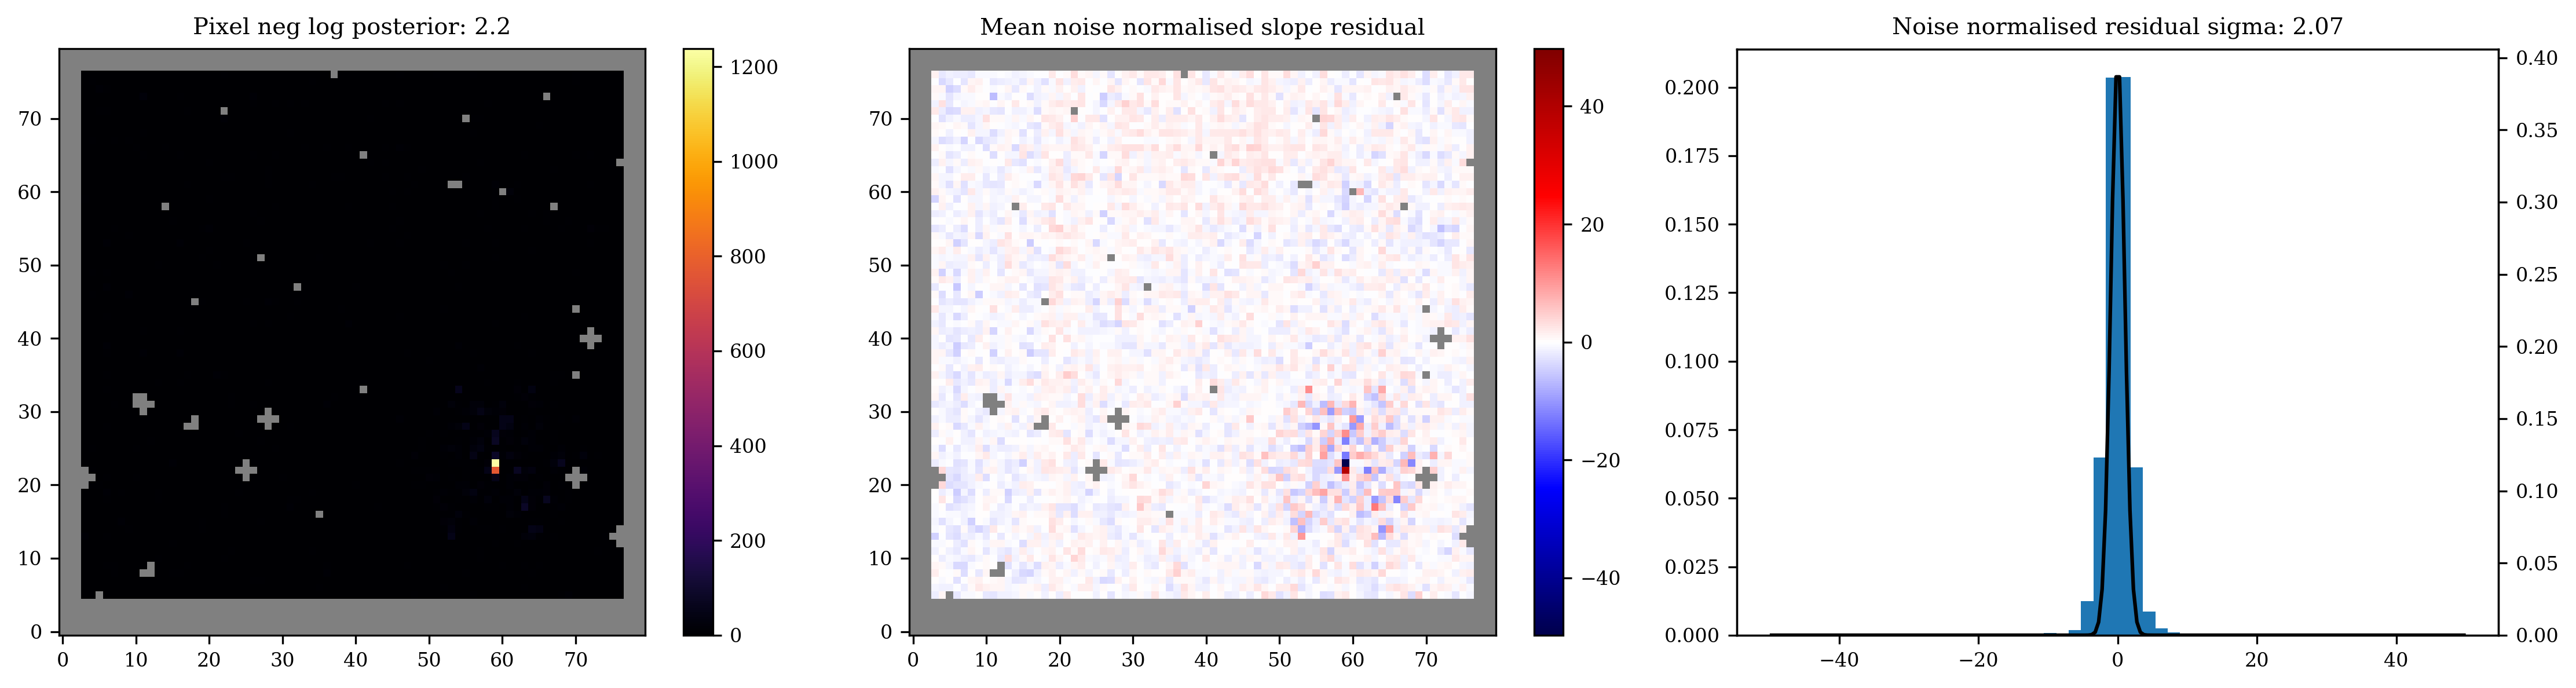

In [ ]:
for exp in exposures:
    print(exp.star)
    print(loss_fn(result.model, exp))
    amigo.plotting.summarise_fit(result.model, exp)

In [ ]:
import jax.tree as jtu
from tqdm.notebook import tqdm
from amigo.fisher import FIM


fmats = {}
for exp in tqdm(exposures):
    # for param in ["amplitudes", "phases"]:
    loglike_fn = lambda model: -np.nansum(log_likelihood(model, exp))

    params = [exp.map_param("amplitudes"), exp.map_param("phases")]
    fmat = FIM(result.model, params, loglike_fn, reduce_ram=True, batch_size=20)
    fmats[exp.get_key("phases")] = fmat

In [ ]:
full_covs = jtu.map(lambda x: np.linalg.inv(x), fmats)

n = vis_model.n_terms
amp_covs = jtu.map(lambda x: x[:n, :n], full_covs)
phase_covs = jtu.map(lambda x: x[n:, n:], full_covs)

covs = {
    "amplitudes": amp_covs,
    "phases": phase_covs,
}

plt.figure(figsize=(20, 10))
for i, key in enumerate(amp_covs):
    if i > 5:
        break

    if i < 3:
        param = "amplitude"
        cov = amp_covs[key]
    else:
        param = "phase"
        cov = amp_covs[key]
    plt.subplot(2, 3, i + 1)
    plt.title(f"{param} Covariance")
    v = np.nanmax(np.abs(cov))
    plt.imshow(cov, seismic, vmin=-v, vmax=v, origin="upper")
    # plt.imshow(np.log10(np.abs(cov)), inferno)
    plt.colorbar()
plt.show()

In [ ]:
filters = sorted(list(set([exp.filter for exp in exposures])))
cal_stars = list(set([exp.star for exp in exposures if exp.calibrator]))
sci_stars = list(set([exp.star for exp in exposures if not exp.calibrator]))
stars = sci_stars + cal_stars

vis_exposures = {
    "cal": [exp for exp in exposures if exp.star in cal_stars],
    "sci": [exp for exp in exposures if exp.star in sci_stars],
}

In [ ]:
from amigo.stats import model_batched_jacobian

# from amigo.vis_models import vis_jac_fn


def vis_jac_fn(model, exp):

    model = model.set("psf_upsample", 1)
    wfs = exp.model_wfs(model)
    wls = wfs.wavelength
    psf_pscale = wfs.pixel_scale[0]

    npix = 2 * model.vis_model.otf_coords.shape[-1]
    pscale = 0.5 * np.diff(model.vis_model.otf_coords[0, 0]).mean()

    # Fourier Functions
    to_uv = vmap(lambda arr, wl: dlu.MFT(arr, wl, psf_pscale, npix, pscale))
    downsample = vmap(lambda arr: dlu.downsample(arr, 2, mean=True))

    # Calculate the visibility maps
    vis = downsample(to_uv(wfs.psf, wls))
    vis = np.mean(vis, axis=0)
    vis = vis.flatten()[: vis.size // 2]

    # # Project the resulting visibilities to the latent space
    log_vis = np.log(vis)
    log_amp, phase = log_vis.real, log_vis.imag
    V_amp_inv = np.linalg.pinv(model.vis_model.V_amp[exp.filter])
    V_phase_inv = np.linalg.pinv(model.vis_model.V_phase[exp.filter])
    return np.dot(log_amp, V_amp_inv), np.dot(phase, V_phase_inv)


pupil_mask = result.model.optics.pupil_mask
mask = pupil_mask.transmission
rms = lambda x: np.sqrt(np.nanmean(np.square(x)))
final_coeffs = {}

params = ["aberrations", "positions"]


thresh = 1e-12
rms_opd = {}
kernel_matrices = {}
zern_matrices = {}
for filt in tqdm(filters):
    for exp in exposures:
        if exp.filter == filt and exp.calibrator:
            break

    # wfs = exp.model_wfs(model)
    # plt.imshow(wfs.psf.sum(0), inferno)
    # plt.colorbar()
    # plt.show()

    amp_fn = lambda model, exp: vis_jac_fn(model, exp)[0]
    amp_fn = lambda model, exp: vis_jac_fn(model, exp)[1]

    # Get the Jacobian
    J_amp = model_batched_jacobian(amp_fn, model, exp, params, n_batch=30)
    J_phase = model_batched_jacobian(amp_fn, model, exp, params, n_batch=30)

    # Get the amplitude Jacobian decomposition4
    u_amp, s_amp, vh_amp = np.linalg.svd(J_amp, full_matrices=True)
    s_amp /= s_amp[0]
    n_keep_amp = np.sum(s_amp < thresh)

    # Get the Jacobian decomposition
    u_phase, s_phase, vh_phase = np.linalg.svd(J_phase, full_matrices=True)
    s_phase /= s_phase[0]
    n_keep_phase = np.sum(s_phase < thresh)

    # Store the outputs
    kernel_matrices[filt] = {
        "amplitudes": u_amp[:, len(s_amp) - n_keep_amp :].T,
        "phases": u_phase[:, len(s_phase) - n_keep_phase :].T,
    }
    zern_matrices[filt] = {
        "amplitudes": u_amp[:, : len(s_amp)].T,
        "phases": u_phase[:, : len(s_phase)].T,
    }

In [ ]:
for filt in filters:
    fig = plt.figure(figsize=(15, 8))
    fig.suptitle(f"{filt}")
    axes = fig.subplot_mosaic(
        [
            ["amp", "phase"],
            ["K_amp", "K_phase"],
        ],
    )

    for star_type, exps in vis_exposures.items():
        if star_type == "cal":
            stars = cal_stars
        else:
            stars = sci_stars

        for exp in exps:
            if exp.filter == filt and exp.star in stars:
                star = exp.star
                key = exp.get_key("amplitudes")

                #
                amp = result.model.get(exp.map_param("amplitudes"))
                amp_cov = amp_covs[exp.get_key("amplitudes")]
                K = kernel_matrices[exp.filter]["amplitudes"]
                # K_amp_cov = np.dot(K, np.dot(amp_cov, K.T))
                K_amp_cov = np.dot(K, np.dot(amp_cov, np.linalg.pinv(K)))
                K_amp = np.dot(K, amp)

                #
                phase = result.model.get(exp.map_param("phases"))
                phase_cov = phase_covs[exp.get_key("phases")]
                K = kernel_matrices[exp.filter]["phases"]
                # K_phase_cov = np.dot(K, np.dot(phase_cov, K.T))
                K_phase_cov = np.dot(K, np.dot(phase_cov, np.linalg.pinv(K)))
                K_phase = np.dot(K, phase)

                amp_err = np.sqrt(np.diag(amp_cov))
                phase_err = np.sqrt(np.diag(phase_cov))
                K_amp_err = np.sqrt(np.diag(K_amp_cov))
                K_phase_err = np.sqrt(np.diag(K_phase_cov))

                #
                amp = 100 * (np.exp(amp) - 1)
                amp_err = 100 * (np.exp(amp_err) - 1)
                K_amp = 100 * (np.exp(K_amp) - 1)
                K_amp_err = 100 * (np.exp(K_amp_err) - 1)

                #
                phase = dlu.rad2deg(phase)
                phase_err = dlu.rad2deg(phase_err)
                K_phase = dlu.rad2deg(K_phase)
                K_phase_err = dlu.rad2deg(K_phase_err)

                inds = np.arange(len(amp))
                K_inds = np.arange(len(K_phase))

                #
                axes["amp"].errorbar(
                    inds,
                    amp,
                    yerr=amp_err,
                    alpha=0.25,
                    label=star,
                    marker="o",
                    capsize=5,
                    ms=5,
                    ls="",
                )
                axes["phase"].errorbar(
                    inds,
                    phase,
                    yerr=phase_err,
                    alpha=0.25,
                    label=star,
                    marker="o",
                    capsize=5,
                    ms=5,
                    ls="",
                )
                axes["K_amp"].errorbar(
                    K_inds,
                    K_amp,
                    yerr=K_amp_err,
                    alpha=0.25,
                    label=star,
                    marker="o",
                    capsize=5,
                    ms=5,
                    ls="",
                )
                axes["K_phase"].errorbar(
                    K_inds,
                    K_phase,
                    yerr=K_phase_err,
                    alpha=0.25,
                    label=star,
                    marker="o",
                    capsize=5,
                    ms=5,
                    ls="",
                )

        axes["amp"].axhline(0, color="k", ls="--", lw=0.5)
        axes["phase"].axhline(0, color="k", ls="--", lw=0.5)
        axes["K_amp"].axhline(0, color="k", ls="--", lw=0.5)
        axes["K_phase"].axhline(0, color="k", ls="--", lw=0.5)

        axes["amp"].set(ylabel="Amplitude (%)", xlabel="index", title="Amplitudes")
        axes["phase"].set(ylabel="Phase (deg)", xlabel="index", title="Phases")
        axes["K_amp"].set(
            ylabel="Amplitude (%)", xlabel="index", title="Kernel Amplitudes"
        )
        axes["K_phase"].set(ylabel="Phase (deg)", xlabel="index", title="Kernel Phases")

        axes["amp"].legend()
        axes["phase"].legend()
        axes["K_amp"].legend()
        axes["K_phase"].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def get_mean_wavelength(wavels, weights):
    """Get the spectrally weighted mean wavelength"""
    return ((wavels * weights).sum() / weights.sum()).mean()


vis_outputs = {}

for filt in filters:

    fig = plt.figure(figsize=(15, 8))
    fig.suptitle(f"{filt}")
    axes = fig.subplot_mosaic(
        [
            ["amp", "phase"],
            ["K_amp", "K_phase"],
        ],
    )

    for star_type, exps in vis_exposures.items():
        if star_type == "cal":
            stars = cal_stars
        else:
            stars = sci_stars

        amps = []
        phases = []
        K_amps = []
        K_phases = []
        amp_covs = []
        phase_covs = []
        K_amp_covs = []
        K_phase_covs = []
        parangs = []
        spectra = []
        for exp in exps:
            if exp.filter == filt and exp.star in stars:
                #
                amp = result.model.get(exp.map_param("amplitudes"))
                amp_cov = covs["amplitudes"][exp.get_key("amplitudes")]
                K = kernel_matrices[exp.filter]["amplitudes"]
                # K_amp_cov = np.dot(K, np.dot(amp_cov, K.T))
                K_amp_cov = np.dot(K, np.dot(amp_cov, np.linalg.pinv(K)))
                K_amp = np.dot(K, amp)
                amps.append(amp)
                K_amps.append(K_amp)
                amp_covs.append(amp_cov)
                K_amp_covs.append(K_amp_cov)

                #
                phase = result.model.get(exp.map_param("phases"))
                phase_cov = covs["phases"][exp.get_key("phases")]
                K = kernel_matrices[exp.filter]["phases"]
                # K_phase_cov = np.dot(K, np.dot(phase_cov, K.T))
                K_phase_cov = np.dot(K, np.dot(phase_cov, np.linalg.pinv(K)))
                K_phase = np.dot(K, phase)
                phases.append(phase)
                K_phases.append(K_phase)
                phase_covs.append(phase_cov)
                K_phase_covs.append(K_phase_cov)

                if star_type == "sci":
                    parangs.append(exp.parang)
                    spectra.append(exp.get_spectra(model))

        amps = np.array(amps).mean(0)
        K_amps = np.array(K_amps).mean(0)
        amp_covs = np.array(amp_covs).mean(0)
        K_amp_covs = np.array(K_amp_covs).mean(0)

        #
        phases = np.array(phases).mean(0)
        K_phases = np.array(K_phases).mean(0)
        phase_covs = np.array(phase_covs).mean(0)
        K_phase_covs = np.array(K_phase_covs).mean(0)

        # Put it all together
        key = f"{star_type}_{filt}"
        vis_outputs[key] = {
            "vis": amps,
            "K_vis": K_amps,
            "vis_cov": amp_cov,
            "K_vis_cov": K_amp_cov,
            "phi": phases,
            "K_phi": K_phases,
            "phi_cov": phase_cov,
            "K_phi_cov": K_phase_cov,
        }

        # Wavelengths & Parallactic angle
        if star_type == "sci":
            assert np.array(parangs).std(0) < 0.1
            vis_outputs[key]["wavel"] = get_mean_wavelength(*np.array(spectra).mean(0))
            vis_outputs[key]["parang"] = np.array(parangs).mean(0)

        # Get the errors
        amp_errs = np.sqrt(np.diag(amp_covs))
        phase_errs = np.sqrt(np.diag(phase_covs))
        K_amp_errs = np.sqrt(np.diag(K_amp_covs))
        K_phase_errs = np.sqrt(np.diag(K_phase_covs))

        # #
        # plt.hist(amp_errs, bins=50)
        # # plt.hist(np.exp(amp_errs))
        # plt.hist(np.exp(amp_errs) - 1, bins=50)
        # plt.show()
        amp = 100 * (1 - np.exp(amps))
        amp_err = 100 * (np.exp(amp_errs) - 1)
        K_amp = 100 * (1 - np.exp(K_amps))
        K_amp_err = 100 * (np.exp(K_amp_errs) - 1)

        #
        phase = dlu.rad2deg(phases)
        phase_err = dlu.rad2deg(phase_errs)
        K_phase = dlu.rad2deg(K_phases)
        K_phase_err = dlu.rad2deg(K_phase_errs)

        inds = np.arange(len(amps))
        K_inds = np.arange(len(K_phase))

        #
        axes["amp"].errorbar(
            inds,
            amp,
            yerr=amp_err,
            alpha=0.25,
            label=star_type,
            marker="o",
            capsize=5,
            ms=5,
            ls="",
        )
        axes["phase"].errorbar(
            inds,
            phase,
            yerr=phase_err,
            alpha=0.25,
            label=star_type,
            marker="o",
            capsize=5,
            ms=5,
            ls="",
        )
        axes["K_amp"].errorbar(
            K_inds,
            K_amp,
            yerr=K_amp_err,
            alpha=0.25,
            label=star_type,
            marker="o",
            capsize=5,
            ms=5,
            ls="",
        )
        axes["K_phase"].errorbar(
            K_inds,
            K_phase,
            yerr=K_phase_err,
            alpha=0.25,
            label=star_type,
            marker="o",
            capsize=5,
            ms=5,
            ls="",
        )

    axes["amp"].axhline(0, color="k", ls="--", lw=0.5)
    axes["phase"].axhline(0, color="k", ls="--", lw=0.5)
    axes["K_amp"].axhline(0, color="k", ls="--", lw=0.5)
    axes["K_phase"].axhline(0, color="k", ls="--", lw=0.5)

    axes["amp"].set(ylabel="Amplitude (%)", xlabel="index", title="Amplitudes")
    axes["phase"].set(ylabel="Phase (deg)", xlabel="index", title="Phases")
    axes["K_amp"].set(ylabel="Amplitude (%)", xlabel="index", title="Kernel Amplitudes")
    axes["K_phase"].set(ylabel="Phase (deg)", xlabel="index", title="Kernel Phases")

    axes["amp"].legend()
    axes["phase"].legend()
    axes["K_amp"].legend()
    axes["K_phase"].legend()

    fig.tight_layout()
    fig.show()

In [ ]:
from amigo.vis_analysis import calibrate_phases


def calibrate_vis(vis_outputs, kernel=True):

    if kernel:
        k_type = "K_"
    else:
        k_type = ""
    # Calibrator values
    cal_key = f"cal_{filt}"
    cal_amp = vis_outputs[cal_key][f"{k_type}vis"]
    cal_phase = vis_outputs[cal_key][f"{k_type}phi"]
    cal_amp_cov = vis_outputs[cal_key][f"{k_type}vis_cov"]
    cal_phase_cov = vis_outputs[cal_key][f"{k_type}phi_cov"]

    # Science values
    sci_key = f"sci_{filt}"
    sci_amp = vis_outputs[sci_key][f"{k_type}vis"]
    sci_phase = vis_outputs[sci_key][f"{k_type}phi"]
    sci_amp_cov = vis_outputs[sci_key][f"{k_type}vis_cov"]
    sci_phase_cov = vis_outputs[sci_key][f"{k_type}phi_cov"]

    # Calibrate
    amp, amp_cov = calibrate_phases(sci_amp, cal_amp, sci_amp_cov, cal_amp_cov)
    phase, phase_cov = calibrate_phases(
        sci_phase, cal_phase, sci_phase_cov, cal_phase_cov
    )

    return {
        f"{k_type}vis": amp,
        f"{k_type}vis_cov": amp_cov,
        f"{k_type}phi": phase,
        f"{k_type}phi_cov": phase_cov,
    }

In [ ]:
cal_vis_outputs = {}
for filt in filters:
    # Calibrate the visibilities
    k_cal_vis_dict = calibrate_vis(vis_outputs, kernel=True)
    cal_vis_dict = calibrate_vis(vis_outputs, kernel=False)

    # Projection matrices
    V_amp = vis_model.V_amp[filt]
    V_phase = vis_model.V_phase[filt]
    K_amp_op = kernel_matrices[filt]["amplitudes"]
    K_phase_op = kernel_matrices[filt]["phases"]
    Z_amp_op = zern_matrices[filt]["amplitudes"]
    Z_phase_op = zern_matrices[filt]["phases"]

    # uv coordinates
    parang = vis_outputs[f"sci_{filt}"]["parang"]
    wavel = vis_outputs[f"sci_{filt}"]["wavel"]

    n = vis_model.n_knots**2 // 2
    u, v = vis_model.otf_coords.reshape(2, -1)[:, :n]
    u, v = dlu.rotate_coords(np.array([u, -v]), -dlu.deg2rad(parang))

    sci_outputs = {
        "u": u,
        "v": v,
        "vis_mat": V_amp,
        "phi_mat": V_phase,
        "K_vis_mat": K_amp_op,
        "K_phi_mat": K_phase_op,
        "Z_vis_mat": Z_amp_op,
        "Z_phi_mat": Z_phase_op,
        "parang": parang,
        "wavel": wavel,
    }

    cal_vis_dict = {**k_cal_vis_dict, **cal_vis_dict, **sci_outputs}
    cal_vis_outputs[filt] = cal_vis_dict
    np.save(output_path + f"calIBRATED.npy", cal_vis_dict, allow_pickle=True)

In [ ]:
for filt in filters:

    K_amp = cal_vis_outputs[filt]["K_vis"]
    K_phase = cal_vis_outputs[filt]["K_phi"]
    K_amp_cov = cal_vis_outputs[filt]["K_vis_cov"]
    K_phase_cov = cal_vis_outputs[filt]["K_phi_cov"]

    # Get the errors
    K_amp_err = np.sqrt(np.diag(K_amp_cov))
    K_phase_err = np.sqrt(np.diag(K_phase_cov))

    # Scale to appropriate units
    K_amp = 100 * (np.exp(K_amp) - 1)
    K_phase = dlu.rad2deg(K_phase)
    K_amp_err = 100 * (np.exp(K_amp_err) - 1)
    K_phase_err = dlu.rad2deg(K_phase_err)

    K_inds = np.arange(len(K_phase))

    fig = plt.figure(figsize=(15, 5))
    fig.suptitle("Calibrated Visibilities")

    axes = fig.subplot_mosaic(
        [
            ["K_amp", "K_phase"],
        ],
    )

    #
    axes["K_amp"].errorbar(
        K_inds,
        K_amp,
        yerr=K_amp_err,
        alpha=0.5,
        label=filt,
        marker="o",
        capsize=5,
        ms=5,
        ls="",
    )
    axes["K_phase"].errorbar(
        K_inds,
        K_phase,
        yerr=K_phase_err,
        alpha=0.5,
        label=filt,
        marker="o",
        capsize=5,
        ms=5,
        ls="",
    )

    axes["K_amp"].axhline(0, color="k", ls="--", lw=0.5)
    axes["K_phase"].axhline(0, color="k", ls="--", lw=0.5)
    axes["K_amp"].set(ylabel="Amplitude (%)", xlabel="index", title="Kernel Amplitudes")
    axes["K_phase"].set(ylabel="Phase (deg)", xlabel="index", title="Kernel Phases")
    fig.tight_layout()
    fig.show()

In [ ]:
from amigo.misc import interp

from jax.scipy.signal import correlate

# mask = optics.pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
mask = pupil_mask.transmission
mask = dlu.downsample(mask, 8, mean=True)
splodges = correlate(mask, mask, method="fft")
splodges /= splodges.max()
splodges = dlu.downsample(splodges, 5, mean=False)
otf_mask = (splodges > 0.25).astype(float)

print(otf_mask.shape)


plt.figure(figsize=(15, 8))
plt.suptitle("Kernel Cleaned Visibilities")
for i, filt in enumerate(cal_vis_outputs.keys()):
    K_vis = cal_vis_outputs[filt]["K_vis"]
    K_phi = cal_vis_outputs[filt]["K_phi"]
    K_vis_mat = cal_vis_outputs[filt]["K_vis_mat"]
    K_phi_mat = cal_vis_outputs[filt]["K_phi_mat"]
    vis_mat = cal_vis_outputs[filt]["vis_mat"]
    phi_mat = cal_vis_outputs[filt]["phi_mat"]

    # u = cal_vis_outputs[filt]["u"]
    # v = cal_vis_outputs[filt]["v"]
    # wl = cal_vis_outputs[filt]["wavel"]

    vis = np.dot(np.linalg.pinv(K_vis_mat), K_vis)
    phi = np.dot(np.linalg.pinv(K_phi_mat), K_phi)

    vis_pix = np.dot(vis, vis_mat)
    phi_pix = np.dot(phi, phi_mat)

    log_amps, phases = amigo.vis_models.vis_to_im(vis_pix, phi_pix, (51, 51))

    knots = dlu.pixel_coords(51, 2)
    samples = dlu.pixel_coords(255, 2)
    log_amps = interp(log_amps, knots, samples)
    phases = interp(phases, knots, samples)

    full_otf = interp(otf_mask, knots, samples)
    log_amps = np.where(full_otf > 0.25, log_amps, np.nan)
    phases = np.where(full_otf > 0.25, phases, np.nan)

    amp = 100 * (np.exp(log_amps) - 1)
    phase = dlu.rad2deg(phases)

    v = np.nanmax(np.abs(amp))
    plt.subplot(2, 3, i + 1)
    plt.title(f"{filt}")
    plt.imshow(amp, seismic, vmin=-v, vmax=v)
    plt.colorbar(label="Amplitude (%)")

    v = np.nanmax(np.abs(phase))
    plt.subplot(2, 3, i + 4)
    plt.title(f"{filt}")
    plt.imshow(phase, seismic, vmin=-v, vmax=v)
    plt.colorbar(label="Phase (deg)")

plt.tight_layout()
plt.show()

In [ ]:
output_path